# S. Appendix

### S.1 Governing Equation

This paper is the comprehensive summary and the explanations on inkjet research about 1D external flow and the MATLAB code. From the work of Eggers et al. (1997), the dynamics of the axisymmetric droplet can be expressed as:

$$
\frac{\partial u}{\partial t}
=
- u \frac{\partial u}{\partial z}
- \frac{1}{\rho}\frac{\partial p}{\partial z}
+ \frac{3\mu}{\rho}\frac{1}{R^{2}} \frac{\partial}{\partial z}
\left(
R^{2}\frac{\partial u}{\partial z}
\right)
\qquad
\tag{S.1}
$$

$$
\frac{\partial R}{\partial t}
=
- u \frac{\partial R}{\partial z}
- \frac{1}{2} R \frac{\partial u}{\partial z}
\qquad
\tag{S.2}
$$

$$
p
=
\gamma
\left(
\frac{1}{R\left(1+\left(\frac{\partial R}{\partial z}\right)^{2}\right)^{1/2}}
-
\frac{\frac{\partial^{2} R}{\partial z^{2}}}
{\left(1+\left(\frac{\partial R}{\partial z}\right)^{2}\right)^{3/2}}
\right)
\qquad
\tag{S.3}
$$

$u$ stands for the axial velocity of the droplet, $R$ for the radius along the axis $z$, $p$ for pressure, $\rho$ for density, $\mu$ for dynamic pressure, and $\gamma$ for the surface tension coefficient.

Here, Eq. (S.1) can be interpreted as the momentum equation, and Eq. (S.2) as the continuity equation. Eq. (S.3) is the explicit expression of the Laplace pressure, which is associated with the surface tension of the fluid, under the assumption that the surface tension is the dominant factor governing the internal pressure of the droplet. See Eggers et al. (1994) for the derivation of the above equations.

---

### S.2 Transient Modeling Based on the Finite Volume Method

As the approximation of the axisymmetric droplet can be approximated as the 1D flow, the finite volume method is very convenient for the transfer of volume along each control volume. On the other side, the provided Eq. (S.1) to (S.3) is rather ambiguous for the application of FVM. Therefore, the momentum equation and the continuity equation has been modified as below (Driessen et al., 2013):

$$
\frac{\partial Au}{\partial t}
=
-
\frac{\partial Au^{2}}{\partial z}
-
\frac{A}{\rho}\frac{\partial p}{\partial z}
+
3\nu \frac{\partial}{\partial z}
\left(
A \frac{\partial u}{\partial z}
\right)
\qquad
\tag{S.4}
$$

$$
\frac{\partial A}{\partial t}
=
-
\frac{\partial Au}{\partial z}
\qquad
\tag{S.5}
$$

Now, this form is much applicable for the finite volume method. Before the discretization, we do non-dimensionalization for the ease of controlling the variables. The non-dimensionalized variables are:

$$
\begin{aligned}
t^{*} &= \frac{t u_{0}}{L_{0}} \\
z^{*} &= \frac{z}{L_{0}} \\
R^{*} &= \frac{R}{L_{0}} \\
A^{*} &= \frac{A}{\pi L_{0}^{2}} \\
u^{*} &= \frac{u}{u_{0}} \\
p^{*} &= \frac{p}{\rho u_{0}^{2}} \\
Re &= \frac{\rho u_{0} L_{0}}{\mu} \\
We &= \frac{\rho u_{0}^{2} L}{\gamma}
\end{aligned}
\qquad
\tag{S.6}
$$

Here $Re$ and $We$ are the Reynolds number and Weber number each. Then the non-dimensionalized equations are:

$$
\frac{\partial A^{*} u^{*}}{\partial t^{*}}
=
-
\frac{\partial A^{*} {u^{*}}^{2}}{\partial z^{*}}
-
A^{*}\frac{\partial p^{*}}{\partial z^{*}}
+
\frac{3}{Re}\frac{\partial}{\partial z^{*}}
\left(
A^{*}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\qquad
\tag{S.7}
$$

$$
\frac{\partial A^{*}}{\partial t^{*}}
=
-
\frac{\partial A^{*} u^{*}}{\partial z^{*}}
\qquad
\tag{S.8}
$$

$$
p^{*}
=
\frac{1}{We}
\left(
\frac{1}{R^{*}\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)^{2}\right)^{1/2}}
-
\frac{\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}}
{\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)^{2}\right)^{3/2}}
\right)
\qquad
\tag{S.9}
$$

From Eq. (S.7), the flux terms can be constructed:

$$
\frac{\partial A^{*} u^{*}}{\partial t^{*}}
=
-
\frac{\partial}{\partial z^{*}}
\left[
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right]
-
A^{*}\frac{\partial p^{*}}{\partial z^{*}}
\qquad
\tag{S.10}
$$

Here, the term $A^{*}\left({u^{*}}^{2} - \frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}\right)$ can be interpreted as the flux through each side with cross-sectional area $A^{*}$. Then, the discretized expressions of Eq. (S.7) and (S.8) using the finite volume method are:

$$
\frac{(A^{*}u^{*})_{i}^{t+1}-(A^{*}u^{*})_{i}^{t}}{\Delta t^{*}}
=
-
\frac{1}{\Delta z^{*}}
\left[
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i+1/2}
-
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i-1/2}
\right]
-
A_{i}^{*}\frac{1}{\Delta z^{*}}
\left(
p_{i+1/2}^{*}-p_{i-1/2}^{*}
\right)
\qquad
\tag{S.11}
$$

$$
\frac{{A^{*}}_{i}^{t+1}-{A^{*}}_{i}^{t}}{\Delta t^{*}}
=
-
\frac{1}{\Delta z^{*}}
\left[
(A^{*}u^{*})_{i+1/2}
-
(A^{*}u^{*})_{i-1/2}
\right]
\qquad
\tag{S.12}
$$

$$
{p^{*}}_{i}^{t+1}
=
\frac{1}{We}
\left(
\frac{1}{R_{i}^{*}\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{1/2}}
-
\frac{\left(\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}\right)_{i}}
{\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{3/2}}
\right)
\qquad
\tag{S.13}
$$

Here only the first order finite difference has been applied on time stepping. Although this approach has the numerical viscosity of $u \Delta z$, which is generally humongous, still, the effect will be negligible under the condition of very small time step and short physical time for the simulation, while having relatively small magnitude of velocity. The higher order scheme is inapplicable due to the very high non-linearity and the ubiquity of singularity during the entire simulation for this problem. On each of the right hand side of the Eq. (S.11) and (S.12), the selection of whether the explicit or the implicit method can be done. For this system, the explicit scheme cannot be applied as there are singularities in every tip of the droplet and the effect of surface tension effect is very non-linear. Even the direct implicit method is also inapplicable due to the high non-linearity. Therefore, the direct iterative method has been applied.

$$
\frac{(A^{*}u^{*})_{i}^{t+k+1}-(A^{*}u^{*})_{i}^{t}}{\Delta t^{*}}
=
-
\frac{1}{\Delta z^{*}}
\left[
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i+1/2}
-
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i-1/2}
\right]^{(t+k)}
-
\left[
A_{i}^{*}\frac{1}{\Delta z^{*}}
\left(
p_{i+1/2}^{*}-p_{i-1/2}^{*}
\right)
\right]^{(t+k)}
\qquad
\tag{S.14}
$$

$$
\frac{{A^{*}}_{i}^{t+k+1}-{A^{*}}_{i}^{t}}{\Delta t^{*}}
=
-
\frac{1}{\Delta z^{*}}
\left[
(A^{*}u^{*})_{i+1/2}
-
(A^{*}u^{*})_{i-1/2}
\right]^{(t+k)}
\qquad
\tag{S.15}
$$

$$
{p^{*}}_{i}^{t+k+1}
=
\frac{1}{We}
\left(
\frac{1}{R_{i}^{*}\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{1/2}}
-
\frac{\left(\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}\right)_{i}}
{\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{3/2}}
\right)^{(t+k)}
\qquad
\tag{S.16}
$$

Here with this approach, each variables (i.e. $\phi$) are being directly updated under the restriction given as the previous time step. Each variables at $i$th node, $t+k+1$th iterations are being simultaneously updated and the iteration continues until the error defined as below reaches the selected limit.

$$
e_{\phi}^{(t+k+1)}
=
\sqrt{
\sum_{i}
\left(
\frac{\phi_{i}^{(t+k+1)}-\phi_{i}^{(t+k)}}
{\phi_{i}^{(t+k)}+\Delta}
\right)^{2}
}
\qquad
\tag{S.17}
$$

$\Delta$ is just a very small number of non-zero to avoid the division by zero, without any physical meaning. More explicit expression of Eq. (S.11) and (S.12) would be

$$
{A^{*}}_{i}^{(t+k+1)}
=
{A^{*}}_{i}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
F_{e,A}-F_{w,A}
\right)^{(t+k)}
\qquad
\tag{S.18}
$$
$$
\begin{aligned}
F_{e,A} &= (A^{*}u^{*})_{i+1/2}^{(t+k)} \\
F_{w,A} &= (A^{*}u^{*})_{i-1/2}^{(t+k)}
\end{aligned}
\qquad
\tag{S.19}
$$

<br>

$$
{u_{i}^{*}}^{(t+k+1)}
=
\frac{1}{{A^{*}}_{i}^{(t+k)}}
\left[
(A^{*}u^{*})_{i}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
F_{e}-F_{w}
\right)
\right]
+
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
p_{i+1/2}^{*}-p_{i-1/2}^{*}
\right)^{(t+k)}
\qquad
\tag{S.20}
$$

$$
\begin{aligned}
F_{e,u} &=
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i+1/2}^{(t+k)} \\
F_{w,u} &=
\left\{
A^{*}
\left(
{u^{*}}^{2}
-
\frac{3}{Re}\frac{\partial u^{*}}{\partial z^{*}}
\right)
\right\}_{i-1/2}^{(t+k)}
\end{aligned}
\qquad
\tag{S.21}
$$

The spatial domain has been discretized in a collocated grid approach, which can be shown as the figure below.

<p align="center">
  <img src="Fig 1..png" alt="Staggered Grid " width="500"><br>
  Fig 1. Staggered Grid  
</p>

Here, for an integer node, the area (radius) and pressure are calculated, whereas the velocity is defined at the half node. Accordingly, the discretized forms of Eqs. (S.18)–(S.21) become:

$$
{A^{*}}_{i}^{(t+k+1)}
=
{A^{*}}_{i}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
F_{e,A}-F_{w,A}
\right)^{(t+k)}
\qquad
\tag{S.22}
$$

$$
\begin{aligned}
F_{e,A}
&=
\frac{\pi}{4}
\left(
{R_{i+1}^{*}}^{(t+k)} + {R_{i}^{*}}^{(t+k)}
\right)^{2}
u_{j+1}^{*}
\\
F_{w,A}
&=
\frac{\pi}{4}
\left(
{R_{i}^{*}}^{(t+k)} + {R_{i-1}^{*}}^{(t+k)}
\right)^{2}
u_{j}^{*}
\end{aligned}
\qquad
\tag{S.23}
$$

<br>

$$
{u_{j}^{*}}^{(t+k+1)}
=
\frac{1}{
\frac{\pi}{4}
\left(
{R_{i}^{*}}^{(t+k)} + {R_{i-1}^{*}}^{(t+k)}
\right)^{2}
}
\left[
\frac{\pi}{4}
\left(
{R_{i}^{*}}^{t} + {R_{i-1}^{*}}^{t}
\right)^{2}
u_{j}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
F_{e}-F_{w}
\right)
\right]
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
p_{i}^{*}-p_{i-1}^{*}
\right)^{(t+k)}
\qquad
\tag{S.24}
$$

$$
\begin{aligned}
F_{e}
&=
{A_{i}^{*}}^{(t+k)}
\left(
\left({u_{j}^{*}}^{(t+k)}\right)^{2}
-
\frac{3}{Re}
\frac{
{u_{j+1}^{*}}^{(t+k)} - {u_{j}^{*}}^{(t+k)}
}{
\Delta z^{*}
}
\right)
\\
F_{w}
&=
{A_{i-1}^{*}}^{(t+k)}
\left(
\left({u_{j-1}^{*}}^{(t+k)}\right)^{2}
-
\frac{3}{Re}
\frac{
{u_{j}^{*}}^{(t+k)} - {u_{j-1}^{*}}^{(t+k)}
}{
\Delta z^{*}
}
\right)
\end{aligned}
\qquad
\tag{S.25}
$$

<br>

$$
{p_{i}^{*}}^{(t+k+1)}
=
\frac{1}{We}
\left(
\frac{1}{
R_{i}^{*}
\left(
1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}
\right)^{1/2}
}
-
\frac{
\left(
\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}
\right)_{i}
}{
\left(
1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}
\right)^{3/2}
}
\right)^{(t+k)}
\qquad
\tag{S.26}
$$

$$
\left(
\frac{\partial R^{*}}{\partial z^{*}}
\right)_{i}^{(t+k)}
=
\frac{
R_{i+1}^{(t+k)} - R_{i-1}^{(t+k)}
}{
2\Delta z^{*}
}
\qquad
\tag{S.27}
$$

$$
\left(
\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}
\right)_{i}^{(t+k)}
=
\frac{
R_{i+1}^{(t+k)} - 2R_{i}^{(t+k)} + R_{i-1}^{(t+k)}
}{
\Delta z^{2}
}
\qquad
\tag{S.28}
$$

Here $j$ indicates the half node, which is equivalent to $j=i-\frac{1}{2}$. For the approximation of the intermediate values of the separate grid, we had used the first order central approximation and the solution has shown no stability issue.



As the iterative solving method has been applied, there exists the effect of numerical diffusion, which results the unphysical filament-like edge being formulated as figure below.

Above figure is the semilog plot of radius without the flux limiter. We need to notice that the $y$ axis is in logarithmic scale and therefore, this indicates the development of very filament-like edge at the bulk of the droplet. This results very high pressure, by the Eq. (S.9), and eventually leads to the divergence of the solution. Therefore the flux limiter has been applied. Unlike conventional method of flux limiters, our approach is to numerically “limit” the mass efflux at the cell with a small radius and enables the efflux for the node with an adequate radius. For our model, there exists the cutoff radius $R_{c}$, determining the deactivation of flux and is named cutoff radius because the operation of “cleansing,” which will be discussed at Section 7, also activates under this criteria. With this method, the mass is appropriately accumulated and the numerical filament is prohibited. Then the continuity equation becomes

$$
{A^{*}}_{i}^{(t+k+1)}
=
{A^{*}}_{i}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
F_{e,A}-F_{w,A}
\right)^{(t+k)}
\qquad
\tag{S.29}
$$

$$
F_{e,A}
=
\begin{cases}
\frac{\pi}{4}
\left(
{R_{i+1}^{*}}^{(t+k)} + {R_{i}^{*}}^{(t+k)}
\right)^{2}
u_{j+1}^{*},
& R_{j} \geq R_{c}
\\
0, & R_{j} < R_{c}
\end{cases}
\qquad
\tag{S.30}
$$

$$
F_{w,A}
=
\begin{cases}
\frac{\pi}{4}
\left(
{R_{i}^{*}}^{(t+k)} + {R_{i-1}^{*}}^{(t+k)}
\right)^{2}
u_{j}^{*},
& R_{j-1} \geq R_{c}
\\
0, & R_{j-1} < R_{c}
\end{cases}
\qquad
\tag{S.31}
$$
---

### S.3 Boundary conditioin

The applied boundary condition is Dirichlet at the starting point of the domain, denoted as $\phi(z=0,t)=\phi_{0}(t)$, where $\phi$ is the solution vector. This enables us to directly control the starting point radius (area) and the flowrate (velocity), resembling the operations as the direct “attachment” of the solution.

A new numerical method was introduced to simulate interfacial flow. Droplet edge, where $R_{\mathrm{edge}} \approx 0$, is a point where the numerical instability happens by the equation of pressure.

$$
p^{*}
=
\frac{1}{We}
\left(
\frac{1}{R^{*}\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)^{2}\right)^{1/2}}
-
\frac{\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}}
{\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)^{2}\right)^{3/2}}
\right)
\qquad
\tag{S.32}
$$

For our model, we had first treated the flux at the edge to be zero as discussed in **S.2 Transient Modeling Based on the Finite Volume Method** so that the numerical diffusion, in the form of a very thin filament, is restricted. With this approach, we made the tip of the droplet “well-attached” near the body of the droplet. This first prohibits the extension of instability near the edge.

The second treatment we made is applying zero Neumann boundary, $\partial_{z}\phi = 0$, about velocity and pressure. This prohibits the development of singularity in pressure where $R_{\mathrm{edge}} \approx 0$, leaving reasonable values for pressure and other variables. Even velocity has been treated as the Neumann boundary because of the difficulty in calculation of gradient, by which the actual displacement of the droplet edge is undefinable and therefore so does the velocity. However, the radius has no boundary condition at the edge for the sake of the conservation of momentum. Therefore, the flux terms as Eq. (S.25) becomes:
$$
F_{e}
=
\begin{cases}
{A_{i}^{*}}^{(t+k)}
\left(
\left({u_{j}^{*}}^{(t+k)}\right)^{2}
-
\frac{3}{Re}
\frac{
{u_{j+1}^{*}}^{(t+k)} - {u_{j}^{*}}^{(t+k)}
}{
\Delta z^{*}
}
\right),
& R_{i} \geq R_{c}
\\
0, & R_{j} < R_{c}
\end{cases}
\qquad
\tag{S.33}
$$

$$
F_{w}
=
\begin{cases}
{A_{i-1}^{*}}^{(t+k)}
\left(
\left({u_{j-1}^{*}}^{(t+k)}\right)^{2}
-
\frac{3}{Re}
\frac{
{u_{j}^{*}}^{(t+k)} - {u_{j-1}^{*}}^{(t+k)}
}{
\Delta z^{*}
}
\right),
& R_{i-1} \geq R_{c}
\\
0, & R_{i-1} < R_{c}
\end{cases}
\qquad
\tag{S.34}
$$

And the momentum equation becomes:

$$
{u_{j}^{*}}^{(t+k+1)}
=
\begin{cases}
{u_{j+1}^{*}}^{(t+k)},
& (R_{i}<R_{c}) \cup (R_{i+1}\geq R_{c})
\\
\frac{1}{{A_{j}^{*}}^{(t+k)}}
\left[
{A_{j}^{*}}^{t}u_{j}^{t}
-
\frac{\Delta t^{*}}{\Delta z^{*}}(F_{e}-F_{w})
\right]
-
\frac{\Delta t^{*}}{\Delta z^{*}}
\left(
p_{i}^{*}-p_{i-1}^{*}
\right)^{(t+k)},
& R_{j}>R_{c}
\\
{u_{j-1}^{*}}^{(t+k)},
& (R_{i-1}\geq R_{c}) \cup (R_{i}<R_{c})
\end{cases}
\qquad
\tag{S.35}
$$

While the pressure is also:

$$
{p_{i}^{*}}^{(t+k+1)}
=
\begin{cases}
{u_{j+1}^{*}}^{(t+k)},
& (R_{i}<R_{c}) \cup (R_{i+1}\geq R_{c})
\\
\frac{1}{We}
\left(
\frac{1}{
R_{i}^{*}\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{1/2}
}
-
\frac{
\left(\frac{\partial^{2} R^{*}}{\partial {z^{*}}^{2}}\right)_{i}
}{
\left(1+\left(\frac{\partial R^{*}}{\partial z^{*}}\right)_{i}^{2}\right)^{3/2}
}
\right)^{(t+k)},
& R_{i}>R_{c}
\\
{u_{j-1}^{*}}^{(t+k)},
& (R_{i-1}\geq R_{c}) \cup (R_{i}<R_{c})
\end{cases}
\qquad
\tag{S.36}
$$

With this approach, we can interpret the droplet problems inside domain $\Omega$ as the sets of individual problems bounded by $\Omega + \partial \Omega \in \Omega$, where $\Omega$ denotes the entire spatial domain for the problem, $\Omega$ for the domain inside the droplet geometry, and $\partial \Omega$ for the edge of the droplet.



---
---

# Numerical method

본 연구에서는 Numerical method 조건 탐색을 위해 ANSYS CFD 모델과 실제 실험을 사용하였다. 이는 물리적 경향성의 정밀도를 유지하기 위해 실제 실험 조건과 동일한 환경에서 물리적 검증을 확인하였다. 실험 측정 장비의 set up은 아래와 같다.

<p align="center">
  <img src="Fig 2..png" alt="Experiment setup" width="700"><br>
  Fig 2. Experiment setup  
</p>

- 개발 된 Axi-symmetric slender jet model은 잉크 물성과 초기 입력 속도를 통해 제어된다. 
- 이를 위해, 잉크 물성 조건은 실제 실험에서 6종류의 에틸렌 글리콜 (EG) 이 사용되었다.
- 초기 입력 속도 조건은 20 V - 40 V 범위의 구동 전압을 통해 노즐 계면의 유동 변위를 측정하여 산출하였다.
- 이는 실제 실험의 물리적 경향성을 확인하여 정밀한 조건을 구성하였다.
- 이후, 동일한 잉크 물성치와 전압 작동 조건의 ANSYS Fluent 모델을 통해 트렌지언트 해석 경향성과 검증하였다. 여기서 사용된 ANSYS Fluent 모델은 선행 연구를 통해 실험과 검증된 바가 있다 (San et al. 2022).  

### - Ink property and voltage conditions

<div align="center">

<table>
  <thead>
    <tr>
      <th>EG</th>
      <th>Surface tension, <i>σ</i> [N/m]</th>
      <th>Dynamic viscosity, <i>μ</i> [Pa·s]</th>
      <th>Density, <i>ρ</i> [kg/m³]</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>EG 100</td><td>0.0474</td><td>0.0157</td><td>1114.00</td></tr>
    <tr><td>EG 90</td><td>0.0497</td><td>0.0105</td><td>1101.00</td></tr>
    <tr><td>EG 75</td><td>0.0521</td><td>0.0064</td><td>1081.00</td></tr>
    <tr><td>EG 65</td><td>0.0539</td><td>0.0049</td><td>1070.00</td></tr>
    <tr><td>EG 60</td><td>0.0551</td><td>0.0041</td><td>1072.00</td></tr>
    <tr><td>EG 50</td><td>0.0565</td><td>0.0030</td><td>1056.00</td></tr>
  </tbody>
</table>

</div>

### - Average velocity conditions

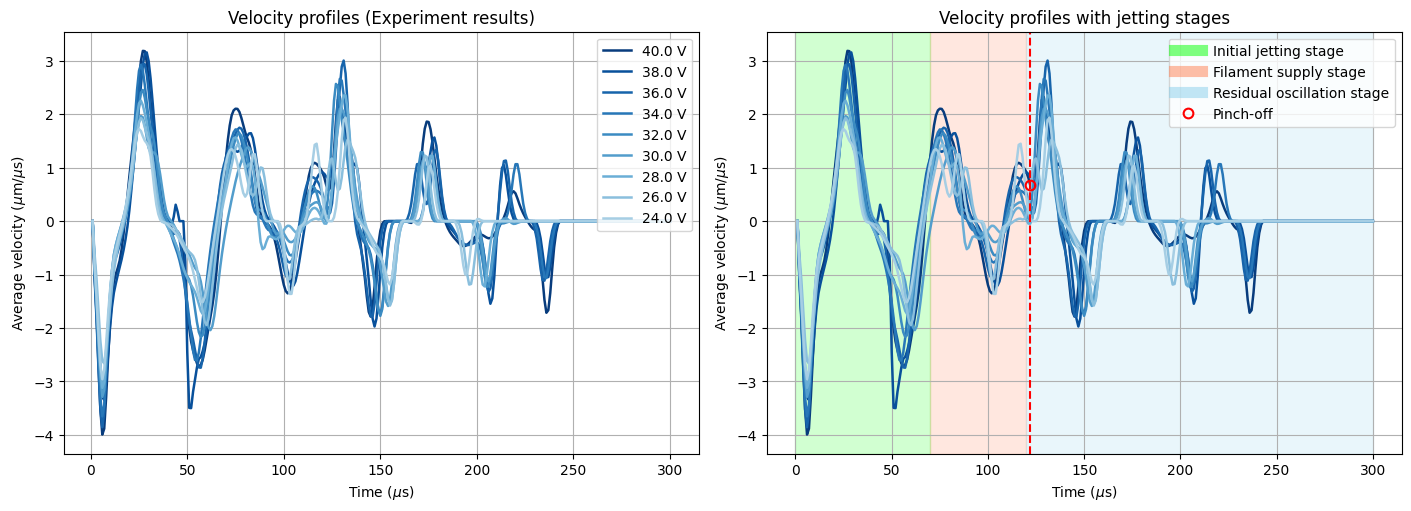

In [151]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = r"D:\Code review\2025-External Flow Dynamics-Finite Volume Method Modeling"
file_name = "Veolcity_profile(Experiment).csv"
file_path = os.path.join(base_dir, file_name)
df = pd.read_csv(file_path)

# ============================================================
# Data preparation
# ============================================================
v_cols = [f"v{i}" for i in range(1, 301)]

for col in v_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

V = df[v_cols].to_numpy(dtype=float)   # shape = (9, 300)
time = np.arange(1, V.shape[1] + 1)

voltages = np.linspace(24, 40, V.shape[0])

cmap = plt.cm.Blues
color_positions = np.linspace(0.35, 0.95, V.shape[0])
colors = [cmap(pos) for pos in color_positions]

# Reverse order: 40 V -> 24 V
plot_order = list(range(V.shape[0] - 1, -1, -1))

# ============================================================
# Visualization
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for i in plot_order:
    ax1.plot(time, V[i], linewidth=1.8, color=colors[i], label=f"{voltages[i]:.1f} V")

ax1.set_xlabel(r"Time ($\mu$s)")
ax1.set_ylabel(r"Average velocity ($\mu$m/$\mu$s)")
ax1.set_title("Velocity profiles (Experiment results)")
ax1.grid(True)
ax1.legend(loc='upper right')

for i in plot_order:
    ax2.plot(time, V[i], linewidth=1.8, color=colors[i])

ax2.axvspan(0, 70, color='lime', alpha=0.18)
ax2.axvspan(70, 120, color='coral', alpha=0.18)
ax2.axvspan(120, 300, color='skyblue', alpha=0.18)
ax2.axvline(122, linestyle='--', linewidth=1.5, color='r')

pinch_idx = np.argmin(np.abs(time - 122))
ax2.plot(
    time[pinch_idx], V[-1, pinch_idx],
    marker='o',
    markerfacecolor='none',
    markeredgecolor='r',
    markeredgewidth=1.5,
    linestyle='None',
    markersize=7
)

ax2.set_xlabel(r"Time ($\mu$s)")
ax2.set_ylabel(r"Average velocity ($\mu$m/$\mu$s)")
ax2.set_title("Velocity profiles with jetting stages")
ax2.grid(True)

region_handles = [
    Line2D([0], [0], color='lime', linewidth=8, alpha=0.5, label='Initial jetting stage'),
    Line2D([0], [0], color='coral', linewidth=8, alpha=0.5, label='Filament supply stage'),
    Line2D([0], [0], color='skyblue', linewidth=8, alpha=0.5, label='Residual oscillation stage'),
    Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.5, linestyle='None', markersize=7, label='Pinch-off')
]
ax2.legend(handles=region_handles, loc='upper right')

plt.show()

### Initial jetting stage

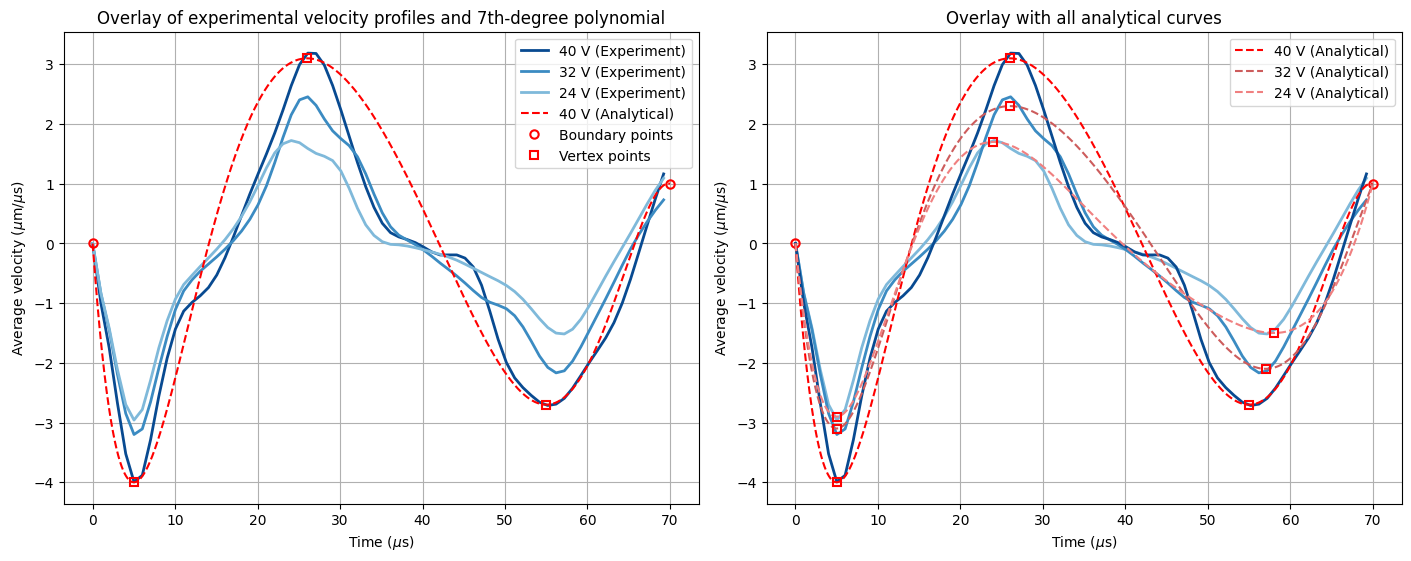

In [150]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Read experimental velocity profiles
# ============================================================
base_dir = r"D:\Code review\2025-External Flow Dynamics-Finite Volume Method Modeling"
file_name = "Veolcity_profile(Experiment).csv"
file_path = os.path.join(base_dir, file_name)

if not os.path.isfile(file_path):
    raise FileNotFoundError(f"CSV file not found:\n{file_path}")

df = pd.read_csv(file_path)

v_cols = [f"v{i}" for i in range(1, 301)]
for col in v_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

V = df[v_cols].to_numpy(dtype=float)   # shape = (n_cases, 300)

# original time axis: 0 ~ 300 us mapped to 300 points
time_us = np.linspace(0, 300, V.shape[1])

# select 0 ~ 70 us only
mask = (time_us >= 0) & (time_us <= 70)
time_sel = time_us[mask]

# voltage row selection
v_24 = V[0]     # 24 V
v_32 = V[4]     # 32 V
v_40 = V[-1]    # 40 V

v24_sel = v_24[mask]
v32_sel = v_32[mask]
v40_sel = v_40[mask]

# ============================================================
# 2. Common boundary conditions
# ============================================================
t0, y0 = 0.0, 0.0
t1, y1 = 70.0, 1.0

# ============================================================
# 3. Vertex-condition sets for analytical curves
# ============================================================
vertex_cases = [
    {"name": "40 V (Analytical)", "ta": 5.0, "ya": -4.0, "dya": 0.0, "tb": 26.0, "yb": 3.1, "dyb": 0.0, "tc": 55.0, "yc": -2.7, "dyc": 0.0},
    {"name": "32 V (Analytical)", "ta": 5.0, "ya": -3.1, "dya": 0.0, "tb": 26.0, "yb": 2.3, "dyb": 0.0, "tc": 57.0, "yc": -2.1, "dyc": 0.0},
    {"name": "24 V (Analytical)", "ta": 5.0, "ya": -2.9, "dya": 0.0, "tb": 24.0, "yb": 1.7, "dyb": 0.0, "tc": 58.0, "yc": -1.5, "dyc": 0.0}
]

# ============================================================
# 4. 7th-degree polynomial builders
# ============================================================
# y(t) = a7*t^7 + a6*t^6 + a5*t^5 + a4*t^4 + a3*t^3 + a2*t^2 + a1*t + a0
def poly_row(t):
    return np.array([t**7, t**6, t**5, t**4, t**3, t**2, t, 1.0], dtype=float)

def dpoly_row(t):
    return np.array([7*t**6, 6*t**5, 5*t**4, 4*t**3, 3*t**2, 2*t, 1.0, 0.0], dtype=float)

def build_polynomial(case):
    ta, ya, dya = case["ta"], case["ya"], case["dya"]
    tb, yb, dyb = case["tb"], case["yb"], case["dyb"]
    tc, yc, dyc = case["tc"], case["yc"], case["dyc"]

    A = np.vstack([
        poly_row(t0), poly_row(t1),
        poly_row(ta), dpoly_row(ta),
        poly_row(tb), dpoly_row(tb),
        poly_row(tc), dpoly_row(tc)
    ])
    b = np.array([y0, y1, ya, dya, yb, dyb, yc, dyc], dtype=float)

    coeffs = np.linalg.solve(A, b)
    poly = np.poly1d(coeffs)
    dpoly = np.polyder(poly)
    return poly, dpoly

# polynomial curve over 0 ~ 70 us
t_poly = np.linspace(t0, t1, 3000)

# ============================================================
# 5. Overlay plots
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Blue gradient colors for experimental curves
cmap = plt.cm.Blues
color_24 = cmap(0.45)
color_32 = cmap(0.65)
color_40 = cmap(0.90)

# Red gradient colors for analytical curves
analytical_colors = ['red', 'indianred', 'lightcoral']

# ============================================================
# ax1: experiment + 40 V analytical only
# ============================================================
ax1.plot(time_sel, v40_sel, linewidth=2, color=color_40, label="40 V (Experiment)")
ax1.plot(time_sel, v32_sel, linewidth=2, color=color_32, label="32 V (Experiment)")
ax1.plot(time_sel, v24_sel, linewidth=2, color=color_24, label="24 V (Experiment)")

poly_40, _ = build_polynomial(vertex_cases[0])
y_poly_40 = poly_40(t_poly)
case40 = vertex_cases[0]

ax1.plot(t_poly, y_poly_40, '--', color='red', linewidth=1.5, label="40 V (Analytical)")
ax1.plot([t0, t1], [y0, y1], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.5, markersize=6, label="Boundary points")
ax1.plot([case40["ta"], case40["tb"], case40["tc"]], [case40["ya"], case40["yb"], case40["yc"]], marker='s', linestyle='None', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.5, markersize=6, label="Vertex points")
ax1.set_xlabel(r"Time ($\mu$s)")
ax1.set_ylabel(r"Average velocity ($\mu$m/$\mu$s)")
ax1.set_title("Overlay of experimental velocity profiles and 7th-degree polynomial")
ax1.grid(True)
ax1.legend(loc='upper right')

# ============================================================
# ax2: experiment + all analytical curves
# ============================================================
ax2.plot(time_sel, v24_sel, linewidth=2, color=color_24)
ax2.plot(time_sel, v32_sel, linewidth=2, color=color_32)
ax2.plot(time_sel, v40_sel, linewidth=2, color=color_40)

ax2.plot([t0, t1], [y0, y1], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.5, markersize=6)

for i, case in enumerate(vertex_cases):
    poly, _ = build_polynomial(case)
    y_poly = poly(t_poly)

    ax2.plot(t_poly, y_poly, '--', color=analytical_colors[i], linewidth=1.5, label=case["name"])
    ax2.plot(
        [case["ta"], case["tb"], case["tc"]],
        [case["ya"], case["yb"], case["yc"]],
        marker='s',
        linestyle='None',
        markerfacecolor='none',
        markeredgecolor='r',
        markeredgewidth=1.5,
        markersize=6,
        label='_nolegend_'
    )

ax2.set_xlabel(r"Time ($\mu$s)")
ax2.set_ylabel(r"Average velocity ($\mu$m/$\mu$s)")
ax2.set_title("Overlay with all analytical curves")
ax2.grid(True)
ax2.legend(loc='upper right')

plt.show()

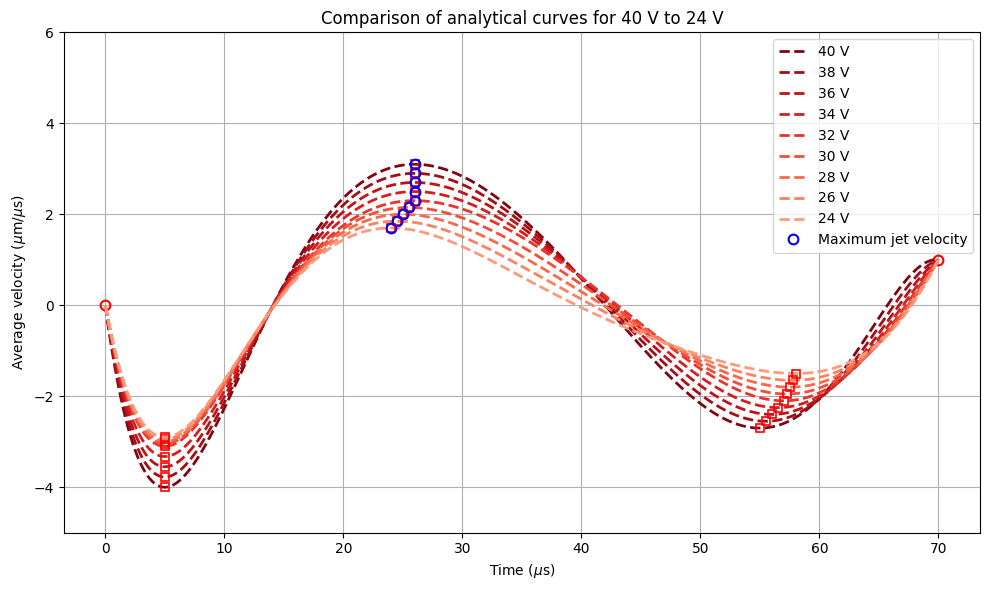

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. Boundary conditions
# ============================================================
t0, y0 = 0.0, 0.0
t1, y1 = 70.0, 1.0

# ============================================================
# 2. Vertex-condition sets
# ============================================================
base_cases = {
    40: {"name": "40 V", "ta": 5.0, "ya": -4.0, "dya": 0.0, "tb": 26.0, "yb": 3.1, "dyb": 0.0, "tc": 55.0, "yc": -2.7, "dyc": 0.0},
    38: {"name": "38 V", "ta": 5.0, "ya": -3.775, "dya": 0.0, "tb": 26.0, "yb": 2.9, "dyb": 0.0, "tc": 55.5, "yc": -2.55, "dyc": 0.0},
    36: {"name": "36 V", "ta": 5.0, "ya": -3.55, "dya": 0.0, "tb": 26.0, "yb": 2.7, "dyb": 0.0, "tc": 56.0, "yc": -2.4, "dyc": 0.0},
    34: {"name": "34 V", "ta": 5.0, "ya": -3.325, "dya": 0.0, "tb": 26.0, "yb": 2.5, "dyb": 0.0, "tc": 56.5, "yc": -2.25, "dyc": 0.0},
    32: {"name": "32 V", "ta": 5.0, "ya": -3.1, "dya": 0.0, "tb": 26.0, "yb": 2.3, "dyb": 0.0, "tc": 57.0, "yc": -2.1, "dyc": 0.0},
    30: {"name": "30 V", "ta": 5.0, "ya": -3.05, "dya": 0.0, "tb": 25.5, "yb": 2.15, "dyb": 0.0, "tc": 57.25, "yc": -1.95, "dyc": 0.0},
    28: {"name": "28 V", "ta": 5.0, "ya": -3.0, "dya": 0.0, "tb": 25.0, "yb": 2.0, "dyb": 0.0, "tc": 57.5, "yc": -1.8, "dyc": 0.0},
    26: {"name": "26 V", "ta": 5.0, "ya": -2.95, "dya": 0.0, "tb": 24.5, "yb": 1.85, "dyb": 0.0, "tc": 57.75, "yc": -1.65, "dyc": 0.0},
    24: {"name": "24 V", "ta": 5.0, "ya": -2.9, "dya": 0.0, "tb": 24.0, "yb": 1.7, "dyb": 0.0, "tc": 58.0, "yc": -1.5, "dyc": 0.0}
}

voltages = [40, 38, 36, 34, 32, 30, 28, 26, 24]
vertex_cases = [base_cases[v] for v in voltages]

# ============================================================
# 3. Polynomial row builders
# ============================================================
def poly_row(t):
    return np.array([t**7, t**6, t**5, t**4, t**3, t**2, t, 1.0], dtype=float)

def dpoly_row(t):
    return np.array([7*t**6, 6*t**5, 5*t**4, 4*t**3, 3*t**2, 2*t, 1.0, 0.0], dtype=float)

# ============================================================
# 4. Build polynomial from one vertex-condition set
# ============================================================
def build_polynomial(case):
    ta, ya, dya = case["ta"], case["ya"], case["dya"]
    tb, yb, dyb = case["tb"], case["yb"], case["dyb"]
    tc, yc, dyc = case["tc"], case["yc"], case["dyc"]

    A = np.vstack([
        poly_row(t0), poly_row(t1),
        poly_row(ta), dpoly_row(ta),
        poly_row(tb), dpoly_row(tb),
        poly_row(tc), dpoly_row(tc)
    ])
    b = np.array([y0, y1, ya, dya, yb, dyb, yc, dyc], dtype=float)

    coeffs = np.linalg.solve(A, b)
    poly = np.poly1d(coeffs)
    dpoly = np.polyder(poly)
    return poly, dpoly

# ============================================================
# 5. Generate and plot all cases
# ============================================================
t = np.linspace(t0, t1, 2000)
plt.figure(figsize=(10, 6))

plt.plot([t0, t1], [y0, y1], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.5, markersize=7)

cmap = plt.cm.Reds
color_positions = np.linspace(0.95, 0.35, len(vertex_cases))
case_colors = [cmap(pos) for pos in color_positions]

for i, case in enumerate(vertex_cases):
    poly, dpoly = build_polynomial(case)
    y = poly(t)
    ta, ya = case["ta"], case["ya"]
    tb, yb = case["tb"], case["yb"]
    tc, yc = case["tc"], case["yc"]

    plt.plot(t, y, linestyle='--', linewidth=2, color=case_colors[i], label=case["name"])
    plt.plot([ta, tb, tc], [ya, yb, yc], marker='s', linestyle='None', markerfacecolor='none', markeredgecolor='r', markeredgewidth=1.2, markersize=6, label='_nolegend_')
    plt.plot(tb, yb, marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='b', markeredgewidth=1.5, markersize=7, label='_nolegend_')

plt.xlabel(r"Time ($\mu$s)")
plt.ylabel(r"Average velocity ($\mu$m/$\mu$s)")
plt.title("Comparison of analytical curves for 40 V to 24 V")
plt.grid(True)
plt.ylim(-5, 6)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='b', markeredgewidth=1.5, markersize=7, label='Maximum jet velocity'))
labels.append('Maximum jet velocity')

plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.show()

### - 검증

---
---

# Results

a. single droplet
b. merging droplet
c. seperate droplet
d. 액적 충돌

Travel distance 조절
---

Re, 

Travel distance 조절
---

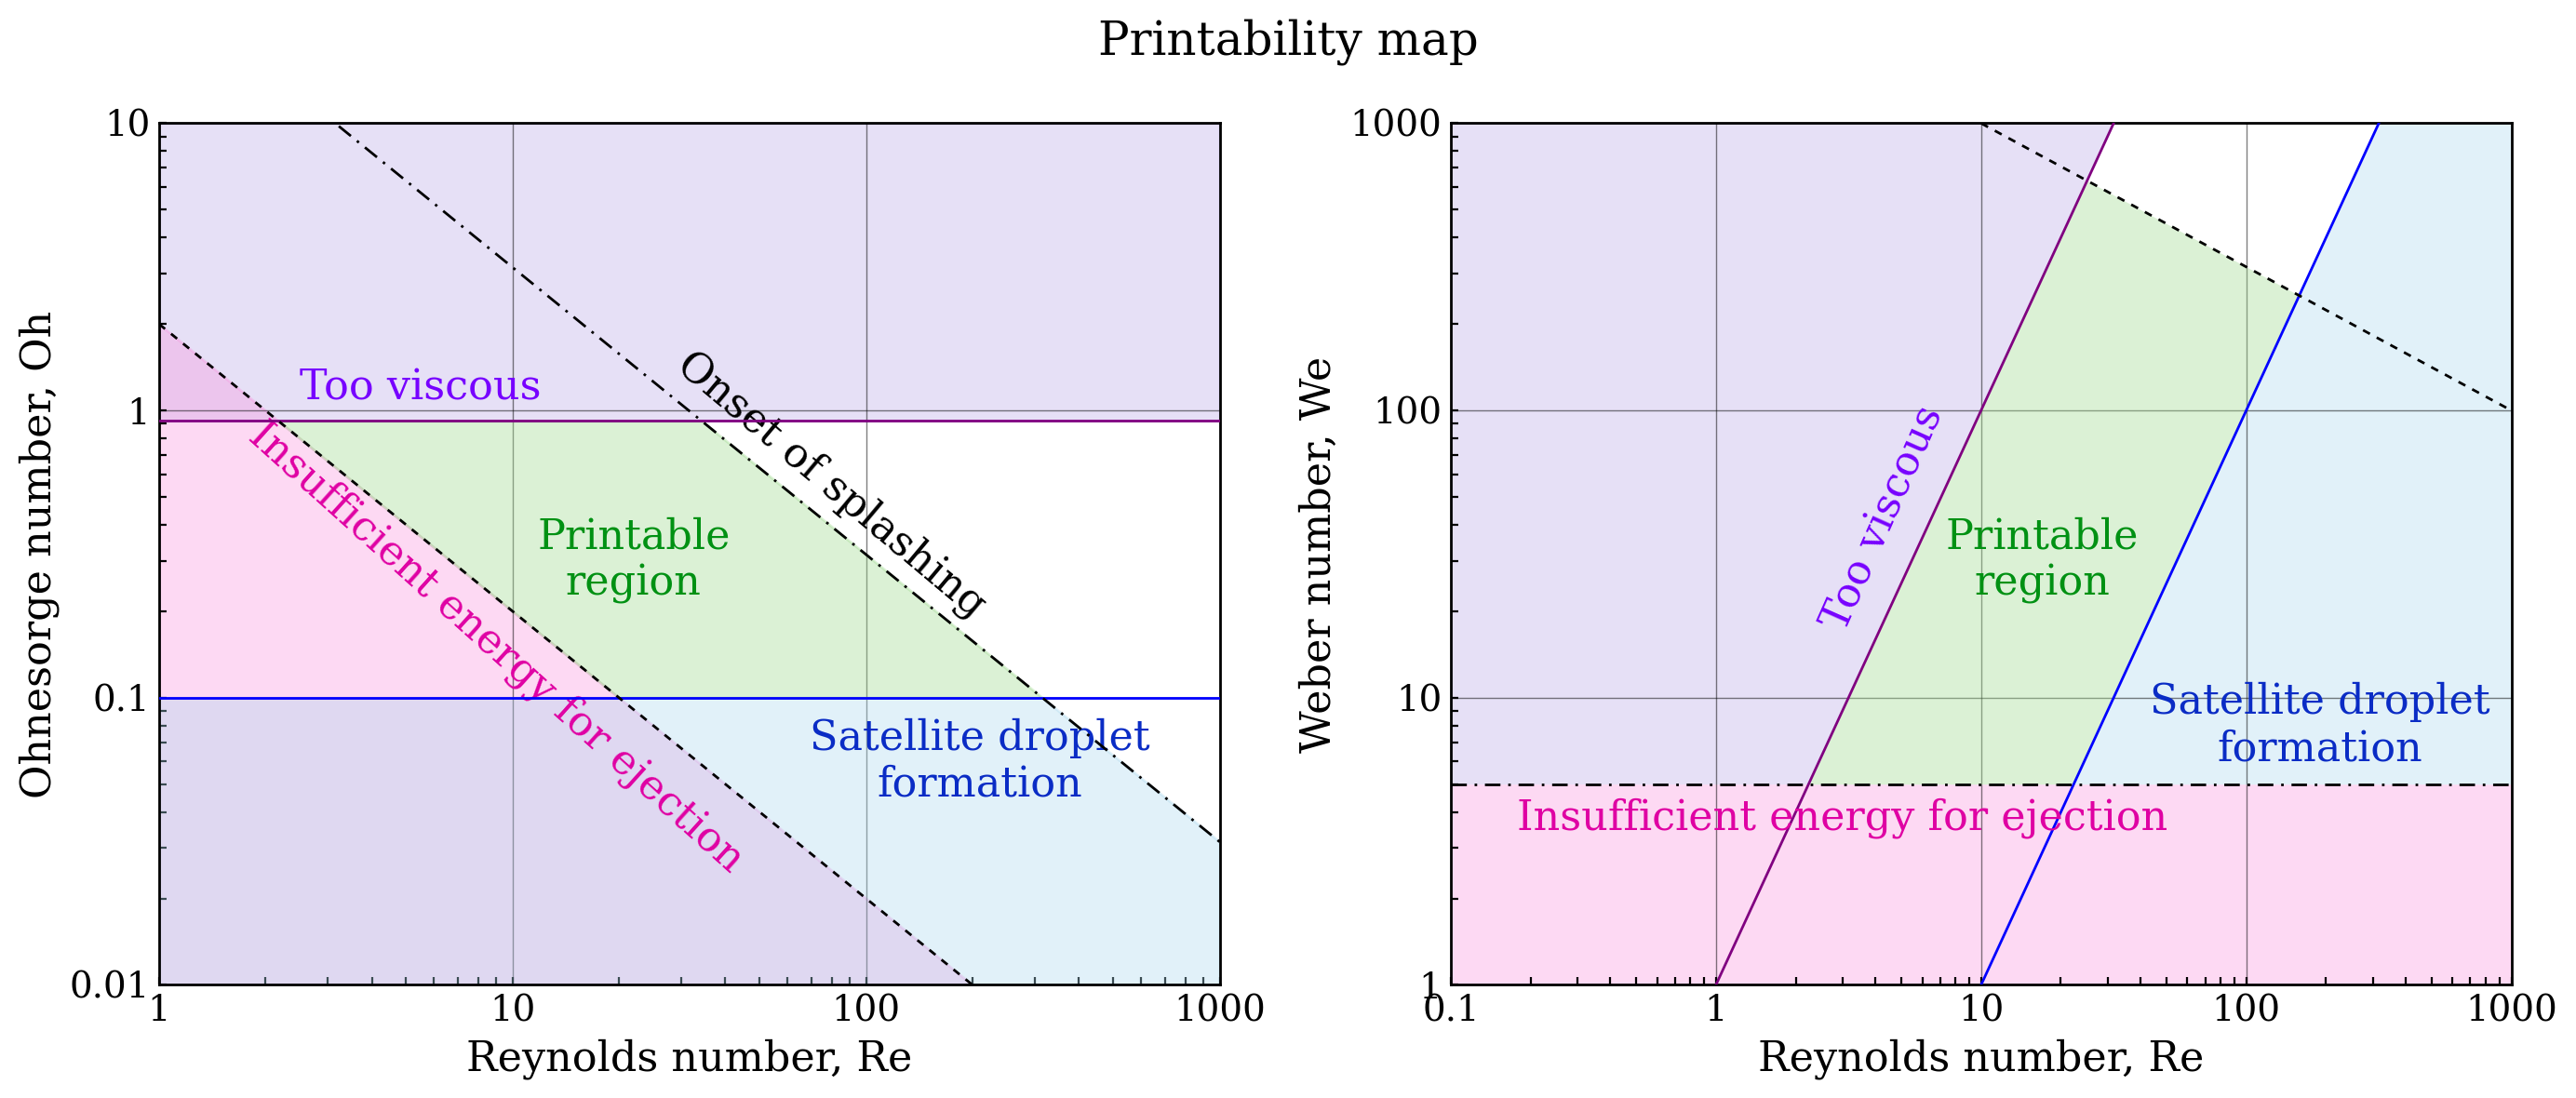

In [349]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({"font.family": "serif","axes.linewidth": 1.0})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200, facecolor="white")
fig.suptitle("Printability map", fontsize=18, y=0.98)

x1 = np.logspace(0, 3, 4000)
x2 = np.logspace(-1, 3, 4000)

# ============================================================
# [ax1] Re-Oh printability map
# ============================================================
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1, 1000)
ax1.set_ylim(0.01, 10)

ax1.set_xlabel("Reynolds number, Re", fontsize=16)
ax1.set_ylabel("Ohnesorge number, Oh", fontsize=16)

# Filled regions
y_low1 = 0.10
y_high1 = 0.92
y_left1 = 2.0 / x1
y_right1 = 31.5 / x1
ymin1, ymax1 = 0.01, 10.0

# Too viscous region:
ax1.fill_between(x1, y_high1, ymax1, color="#b8a7e6", alpha=0.35, zorder=0)

# Insufficient energy region: 
mask_ins1 = y_left1 > ymin1
ax1.fill_between(x1[mask_ins1], ymin1, np.minimum(y_left1[mask_ins1], ymax1), where=np.minimum(y_left1[mask_ins1], ymax1) > ymin1, color="#fa93df", alpha=0.35, zorder=1)

# Satellite droplet formation region: 
mask_sat1 = y_right1 > ymin1
ax1.fill_between(x1[mask_sat1], ymin1, np.minimum(y_right1[mask_sat1], y_low1), where=np.minimum(y_right1[mask_sat1], y_low1) > ymin1, color="#a9d8ee", alpha=0.35, zorder=2)

# Printable region: 
y_bottom1 = np.maximum(np.full_like(x1, y_low1), y_left1)
y_top1 = np.minimum(np.full_like(x1, y_high1), y_right1)
mask_print1 = y_top1 > y_bottom1
ax1.fill_between(x1[mask_print1], y_bottom1[mask_print1], y_top1[mask_print1],color="#9ad889", alpha=0.35, zorder=3)

# Boundary lines
ax1.axhline(y_high1, color="purple", linewidth=1.0, zorder=4)
ax1.axhline(y_low1, color="blue", linewidth=1.0, zorder=4)
ax1.plot(x1, y_left1, linestyle=(0, (3, 3)), color="black", linewidth=1.0, zorder=5)
ax1.plot(x1, y_right1, linestyle=(0, (6, 3, 1, 3)), color="black", linewidth=1.0, zorder=5)

# Reference
ax1.text(2.5, 1.2, "Too viscous", color="#7700ff", fontsize=16, ha="left", va="center")
ax1.text(22, 0.3, "Printable\nregion", color="#009113", fontsize=16, ha="center", va="center")
ax1.text(210, 0.06, "Satellite droplet\nformation", color="#0a2cc5", fontsize=16, ha="center", va="center")
ax1.text(9.0, 0.15, "Insufficient energy for ejection", color="#df00a3", fontsize=16, rotation=-42, ha="center", va="center")
ax1.text(80, 0.55, "Onset of splashing", color="black", fontsize=16, rotation=-40, ha="center", va="center")

# Layout
ax1.set_xticks([1, 10, 100, 1000])
ax1.set_xticklabels(["1", "10", "100", "1000"], fontsize=12)
ax1.set_yticks([0.01, 0.1, 1, 10])
ax1.set_yticklabels(["0.01", "0.1", "1", "10"], fontsize=12)
ax1.tick_params(which="both", direction="in", length=3, width=0.8, labelsize=14)
ax1.grid(True, which="major", axis="both", color="k", alpha=0.5, linewidth=0.5)
ax1.set_facecolor("white")
x1 = np.logspace(0, 3, 4000)

# ============================================================
# [ax2] Re-We printability map
# ============================================================
ax2.set_facecolor("white")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(0.1, 1000)
ax2.set_ylim(1, 1000)

ax2.set_xlabel("Reynolds number, Re", fontsize=16)
ax2.set_ylabel("Weber number, We", fontsize=16)

# Filled regions
y_low2 = 5.0
y_left2 = x2**2
y_right2 = 0.01 * x2**2
y_high2 = 3162.27766017 / np.sqrt(x2)
ymin2, ymax2 = 1.0, 1000.0

# Too viscous region:
y1_purple2 = np.maximum(y_left2, y_low2)
mask_purple2 = y1_purple2 < ymax2
ax2.fill_between(x2[mask_purple2], y1_purple2[mask_purple2], ymax2, color="#b8a7e6", alpha=0.35, linewidth=0, zorder=1)

# Insufficient energy region: 
ax2.fill_between(x2, ymin2, y_low2, color="#fa93df", alpha=0.35, linewidth=0, zorder=1)

# Satellite droplet formation region: 
mask_blue2 = y_right2 > y_low2
ax2.fill_between(x2[mask_blue2], y_low2, np.minimum(y_right2[mask_blue2], ymax2), color="#a9d8ee", alpha=0.35, linewidth=0, zorder=1)

# Printable region: 
y_bottom_green2 = np.maximum(y_low2, y_right2)
y_top_green2 = np.minimum(np.minimum(y_left2, y_high2), ymax2)
mask_green2 = y_top_green2 > y_bottom_green2
ax2.fill_between(x2[mask_green2], y_bottom_green2[mask_green2], y_top_green2[mask_green2],  color="#9ad889", alpha=0.35, linewidth=0, zorder=2)

# Boundary lines
mask_left2 = (y_left2 >= ymin2) & (y_left2 <= ymax2)
ax2.plot(x2[mask_left2], y_left2[mask_left2], color="purple", linewidth=1.0, zorder=5)
mask_right2 = (y_right2 >= ymin2) & (y_right2 <= ymax2)
ax2.plot(x2[mask_right2], y_right2[mask_right2], color="blue", linewidth=1.0, zorder=5)
mask_high2 = (y_high2 >= ymin2) & (y_high2 <= ymax2)
ax2.plot(x2[mask_high2], y_high2[mask_high2], linestyle=(0, (3, 3)), color="black", linewidth=1.0, zorder=6)
ax2.hlines(y_low2, x2.min(), x2.max(), linestyle=(0, (6, 3, 1, 3)), color="black", linewidth=1.0, zorder=6)

# Reference
ax2.text(4.3, 42, "Too viscous", color="#7700ff", fontsize=16, rotation=66, ha="center", va="center", zorder=7)
ax2.text(17, 30, "Printable\nregion", color="#009113", fontsize=16, ha="center", va="center", zorder=7)
ax2.text(190, 8, "Satellite droplet\nformation", color="#0a2cc5", fontsize=16, ha="center", va="center", zorder=7)
ax2.text(3, 3.8, "Insufficient energy for ejection", color="#df00a3", fontsize=16, ha="center", va="center", zorder=7)

# Layout
ax2.set_xticks([0.1, 1, 10, 100, 1000])
ax2.set_xticklabels([0.1, "1", "10", "100", "1000"], fontsize=12)
ax2.set_yticks([1, 10, 100, 1000])
ax2.set_yticklabels(["1", "10", "100", "1000"], fontsize=12)
ax2.tick_params(which="both", direction="in", length=3, width=0.8, labelsize=14)
ax2.grid(True, which="major", axis="both", color="k", alpha=0.5, linewidth=0.5)
x2 = np.logspace(-1, 3, 4000)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Equations
# ============================================================
def calc_Re(rho, U, D, mu):
    return rho * U * D / mu

def calc_We(rho, U, D, sigma):
    return rho * (U ** 2) * D / sigma

def calc_Oh(rho, mu, sigma, D):
    return mu / np.sqrt(rho * sigma * D)

# ============================================================
# Calculate results
# ============================================================
def build_results(voltage_cases, U_dict, rho, mu, sigma, D):
    results = {}
    for V in voltage_cases:
        U = U_dict[V]
        results[V] = {
            "Re": calc_Re(rho, U, D, mu),
            "We": calc_We(rho, U, D, sigma),
            "Oh": calc_Oh(rho, mu, sigma, D)
        }
    return results

# ============================================================
# Voltage-to-color mapping
# 20 V -> blue, 40 V -> magenta
# ============================================================
def voltage_to_color(voltage_label):
    v = float(voltage_label.replace(" V", ""))
    t = (v - 20.0) / (40.0 - 20.0)

    blue = np.array([0.0, 0.0, 1.0])
    magenta = np.array([1.0, 0.0, 1.0])

    rgb = (1.0 - t) * blue + t * magenta
    return tuple(rgb)

# ============================================================
# Plot function
# ============================================================
def plot_printability_maps(results):
    plt.rcParams.update({"font.family": "serif", "axes.linewidth": 1.0})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200, facecolor="white")
    fig.suptitle("Printability map", fontsize=18, y=0.98)

    # ========================================================
    # x arrays
    # ========================================================
    x1 = np.logspace(0, 3, 4000)
    x2 = np.logspace(-1, 3, 4000)

    # ========================================================
    # [ax1] Re-Oh printability map
    # ========================================================
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlim(1, 1000)
    ax1.set_ylim(0.01, 10)

    ax1.set_xlabel("Reynolds number, Re", fontsize=16)
    ax1.set_ylabel("Ohnesorge number, Oh", fontsize=16)

    # Filled regions
    y_low1 = 0.10
    y_high1 = 0.92
    y_left1 = 2.0 / x1
    y_right1 = 31.5 / x1
    ymin1, ymax1 = 0.01, 10.0

    # Too viscous region:
    ax1.fill_between(x1, y_high1, ymax1, color="#b8a7e6", alpha=0.35, zorder=0)

    # Insufficient energy region:
    mask_ins1 = y_left1 > ymin1
    ax1.fill_between(x1[mask_ins1], ymin1, np.minimum(y_left1[mask_ins1], ymax1), where=np.minimum(y_left1[mask_ins1], ymax1) > ymin1, color="#fa93df", alpha=0.35, zorder=1)

    # Satellite droplet formation region:
    mask_sat1 = y_right1 > ymin1
    ax1.fill_between(x1[mask_sat1], ymin1, np.minimum(y_right1[mask_sat1], y_low1), where=np.minimum(y_right1[mask_sat1], y_low1) > ymin1, color="#a9d8ee", alpha=0.35, zorder=2)

    # Printable region:
    y_bottom1 = np.maximum(np.full_like(x1, y_low1), y_left1)
    y_top1 = np.minimum(np.full_like(x1, y_high1), y_right1)
    mask_print1 = y_top1 > y_bottom1
    ax1.fill_between(x1[mask_print1], y_bottom1[mask_print1], y_top1[mask_print1], color="#9ad889", alpha=0.35, zorder=3)

    # Boundary lines
    ax1.axhline(y_high1, color="purple", linewidth=1.0, zorder=4)
    ax1.axhline(y_low1, color="blue", linewidth=1.0, zorder=4)
    ax1.plot(x1, y_left1, linestyle=(0, (3, 3)), color="black", linewidth=1.0, zorder=5)
    ax1.plot(x1, y_right1, linestyle=(0, (6, 3, 1, 3)), color="black", linewidth=1.0, zorder=5)

    # Layout
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(["1", "10", "100", "1000"], fontsize=12)
    ax1.set_yticks([0.01, 0.1, 1, 10])
    ax1.set_yticklabels(["0.01", "0.1", "1", "10"], fontsize=12)
    ax1.tick_params(which="both", direction="in", length=3, width=0.8)
    ax1.grid(True, which="major", axis="both", color="k", alpha=0.5, linewidth=0.5)
    ax1.set_facecolor("white")

    # Scatter points from results on Re-Oh map
    for V in voltage_cases: c = voltage_to_color(V); ax1.plot(results[V]["Re"], results[V]["Oh"], marker="o", markersize=7, markerfacecolor="none", markeredgecolor=c, markeredgewidth=1.5, linestyle="None", zorder=10)
    legend_order = voltage_cases[::-1]
    legend_handles_ax1 = [Line2D([0], [0], marker="o", linestyle="None", markersize=7, markerfacecolor="none", markeredgecolor=voltage_to_color(V), markeredgewidth=2.0, label=V) for V in legend_order]

    leg1 = ax1.legend(handles=legend_handles_ax1, loc="upper right", frameon=True, fontsize=10, edgecolor="black", facecolor="white", framealpha=0.75)
    leg1.get_frame().set_linewidth(1.0)

    # ========================================================
    # [ax2] Re-We printability map
    # ========================================================
    ax2.set_facecolor("white")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlim(0.1, 1000)
    ax2.set_ylim(1, 1000)

    ax2.set_xlabel("Reynolds number, Re", fontsize=16)
    ax2.set_ylabel("Weber number, We", fontsize=16)

    # Filled regions
    y_low2 = 5.0
    y_left2 = x2**2
    y_right2 = 0.01 * x2**2
    y_high2 = 3162.27766017 / np.sqrt(x2)
    ymin2, ymax2 = 1.0, 1000.0

    # Too viscous region:
    y1_purple2 = np.maximum(y_left2, y_low2)
    mask_purple2 = y1_purple2 < ymax2
    ax2.fill_between(x2[mask_purple2], y1_purple2[mask_purple2], ymax2, color="#b8a7e6", alpha=0.35, linewidth=0, zorder=1)

    # Insufficient energy region:
    ax2.fill_between(x2, ymin2, y_low2, color="#fa93df", alpha=0.35, linewidth=0, zorder=1)

    # Satellite droplet formation region:
    mask_blue2 = y_right2 > y_low2
    ax2.fill_between(x2[mask_blue2], y_low2, np.minimum(y_right2[mask_blue2], ymax2), color="#a9d8ee", alpha=0.35, linewidth=0, zorder=1)

    # Printable region:
    y_bottom_green2 = np.maximum(y_low2, y_right2)
    y_top_green2 = np.minimum(np.minimum(y_left2, y_high2), ymax2)
    mask_green2 = y_top_green2 > y_bottom_green2
    ax2.fill_between(x2[mask_green2], y_bottom_green2[mask_green2], y_top_green2[mask_green2], color="#9ad889", alpha=0.35, linewidth=0, zorder=2)

    # Boundary lines
    mask_left2 = (y_left2 >= ymin2) & (y_left2 <= ymax2)
    ax2.plot(x2[mask_left2], y_left2[mask_left2], color="purple", linewidth=1.0, zorder=5)

    mask_right2 = (y_right2 >= ymin2) & (y_right2 <= ymax2)
    ax2.plot(x2[mask_right2], y_right2[mask_right2], color="blue", linewidth=1.0, zorder=5)

    mask_high2 = (y_high2 >= ymin2) & (y_high2 <= ymax2)
    ax2.plot(x2[mask_high2], y_high2[mask_high2], linestyle=(0, (3, 3)), color="black", linewidth=1.0, zorder=6)

    ax2.hlines(y_low2, x2.min(), x2.max(), linestyle=(0, (6, 3, 1, 3)), color="black", linewidth=1.0, zorder=6)

    # Layout
    ax2.set_xticks([0.1, 1, 10, 100, 1000])
    ax2.set_xticklabels(["0.1", "1", "10", "100", "1000"], fontsize=12)
    ax2.set_yticks([1, 10, 100, 1000])
    ax2.set_yticklabels(["1", "10", "100", "1000"], fontsize=12)
    ax2.tick_params(which="both", direction="in", length=3, width=0.8)
    ax2.grid(True, which="major", axis="both", color="k", alpha=0.5, linewidth=0.5)


    # Scatter points from results on Re-We map
    for V in voltage_cases: c = voltage_to_color(V); ax2.plot(results[V]["Re"], results[V]["We"], marker="o", markersize=7, markerfacecolor="none", markeredgecolor=c, markeredgewidth=1.5, linestyle="None", zorder=10)
    legend_handles_ax2 = [Line2D([0], [0], marker="o", linestyle="None", markersize=7, markerfacecolor="none", markeredgecolor=voltage_to_color(V), markeredgewidth=2.0, label=V) for V in legend_order]
    leg2 = ax2.legend(handles=legend_handles_ax2, loc="upper right", frameon=True, fontsize=10, edgecolor="black", facecolor="white", framealpha=0.75)
    leg2.get_frame().set_linewidth(1.0)


    plt.tight_layout()
    plt.show()

EG 100

20 V -> Re = 7.095541, We = 4.700422, Oh = 0.305550
22 V -> Re = 7.805096, We = 5.687511, Oh = 0.305550
24 V -> Re = 8.514650, We = 6.768608, Oh = 0.305550
26 V -> Re = 9.224204, We = 7.943713, Oh = 0.305550
28 V -> Re = 9.933758, We = 9.212827, Oh = 0.305550
30 V -> Re = 10.643312, We = 10.575949, Oh = 0.305550
32 V -> Re = 11.352866, We = 12.033080, Oh = 0.305550
34 V -> Re = 12.062420, We = 13.584219, Oh = 0.305550
36 V -> Re = 12.771975, We = 15.229367, Oh = 0.305550
38 V -> Re = 13.481529, We = 16.968523, Oh = 0.305550
40 V -> Re = 14.191083, We = 18.801688, Oh = 0.305550


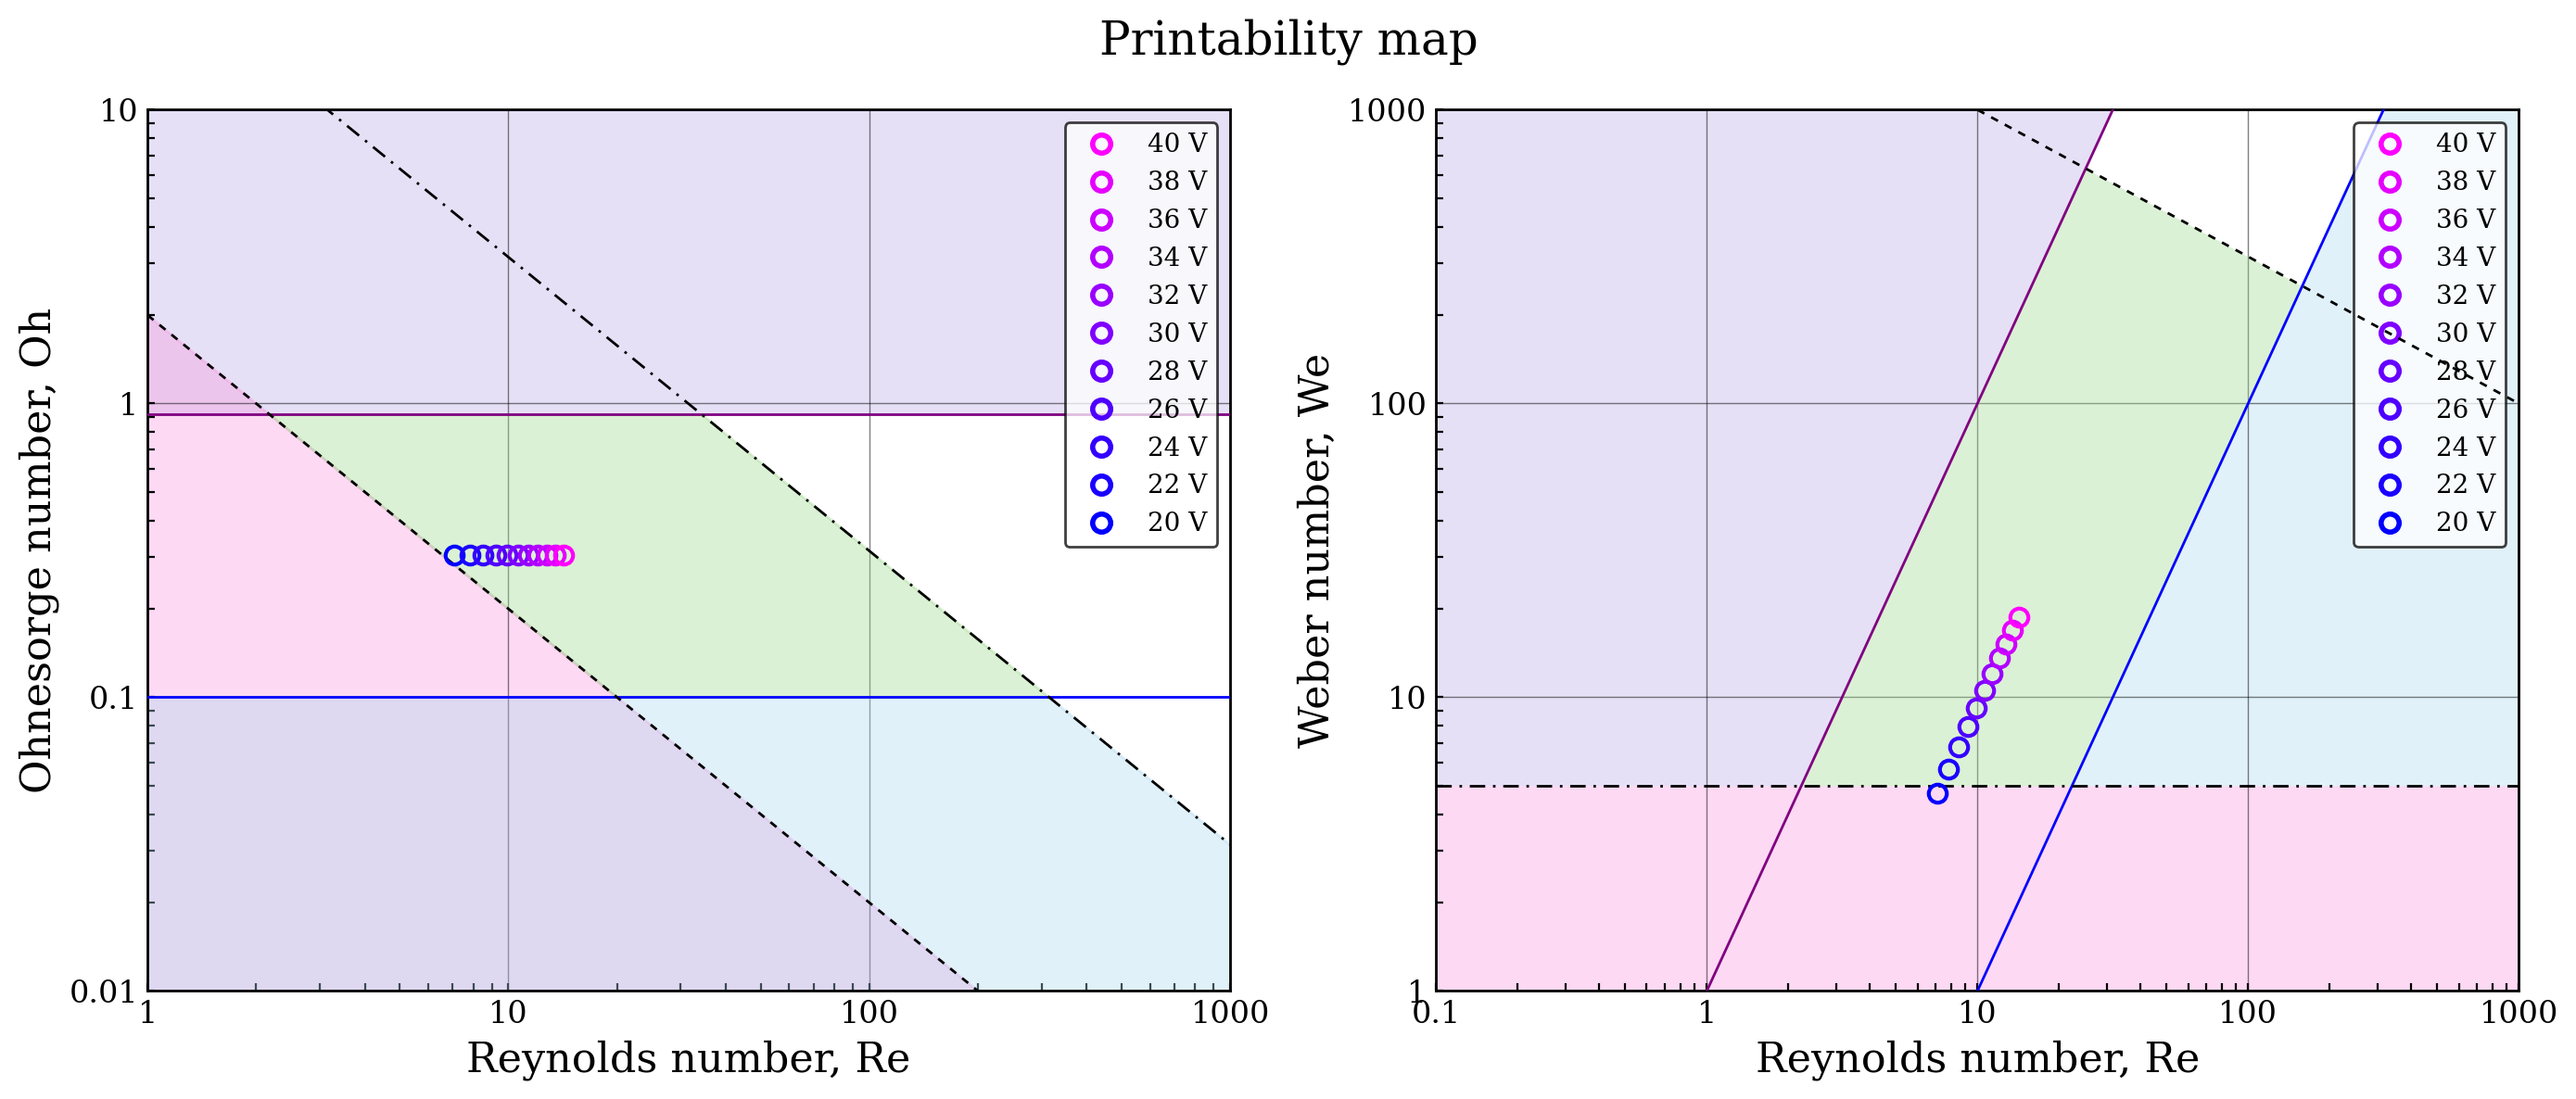

In [7]:
# ============================================================
# Voltage cases
# ============================================================
voltage_cases = ["20 V", "22 V", "24 V", "26 V", "28 V", "30 V", "32 V", "34 V", "36 V", "38 V", "40 V"]
#voltage_cases = ["20 V", "22 V"]
#     {'name': 'EG 100', 'sigma': 0.0474, 'mu': 0.0157, 'rho': 1114.00, 'alpha': 0.29e-9, 'c': 1688.00},

# ============================================================
# SI units
# rho   : kg/m^3
# mu    : Pa*s
# sigma : N/m
# D     : m
# U     : m/s
# ============================================================
rho = 1114.0
mu = 0.0157
sigma = 0.0474
D = 50e-6

# Characteristic velocity for each voltage case [m/s]
U_dict = {"20 V": 2.0, "22 V": 2.2, "24 V": 2.4, "26 V": 2.6, "28 V": 2.8, "30 V": 3.0, "32 V": 3.2, "34 V": 3.4, "36 V": 3.6, "38 V": 3.8, "40 V": 4.0}
#U_dict = {"20 V": 1.7, "22 V": 3.1}


# ============================================================
# Run
# ============================================================
results = build_results(voltage_cases, U_dict, rho, mu, sigma, D)

for case, values in results.items():
    print(f"{case} -> Re = {values['Re']:.6f}, We = {values['We']:.6f}, Oh = {values['Oh']:.6f}")

plot_printability_maps(results)

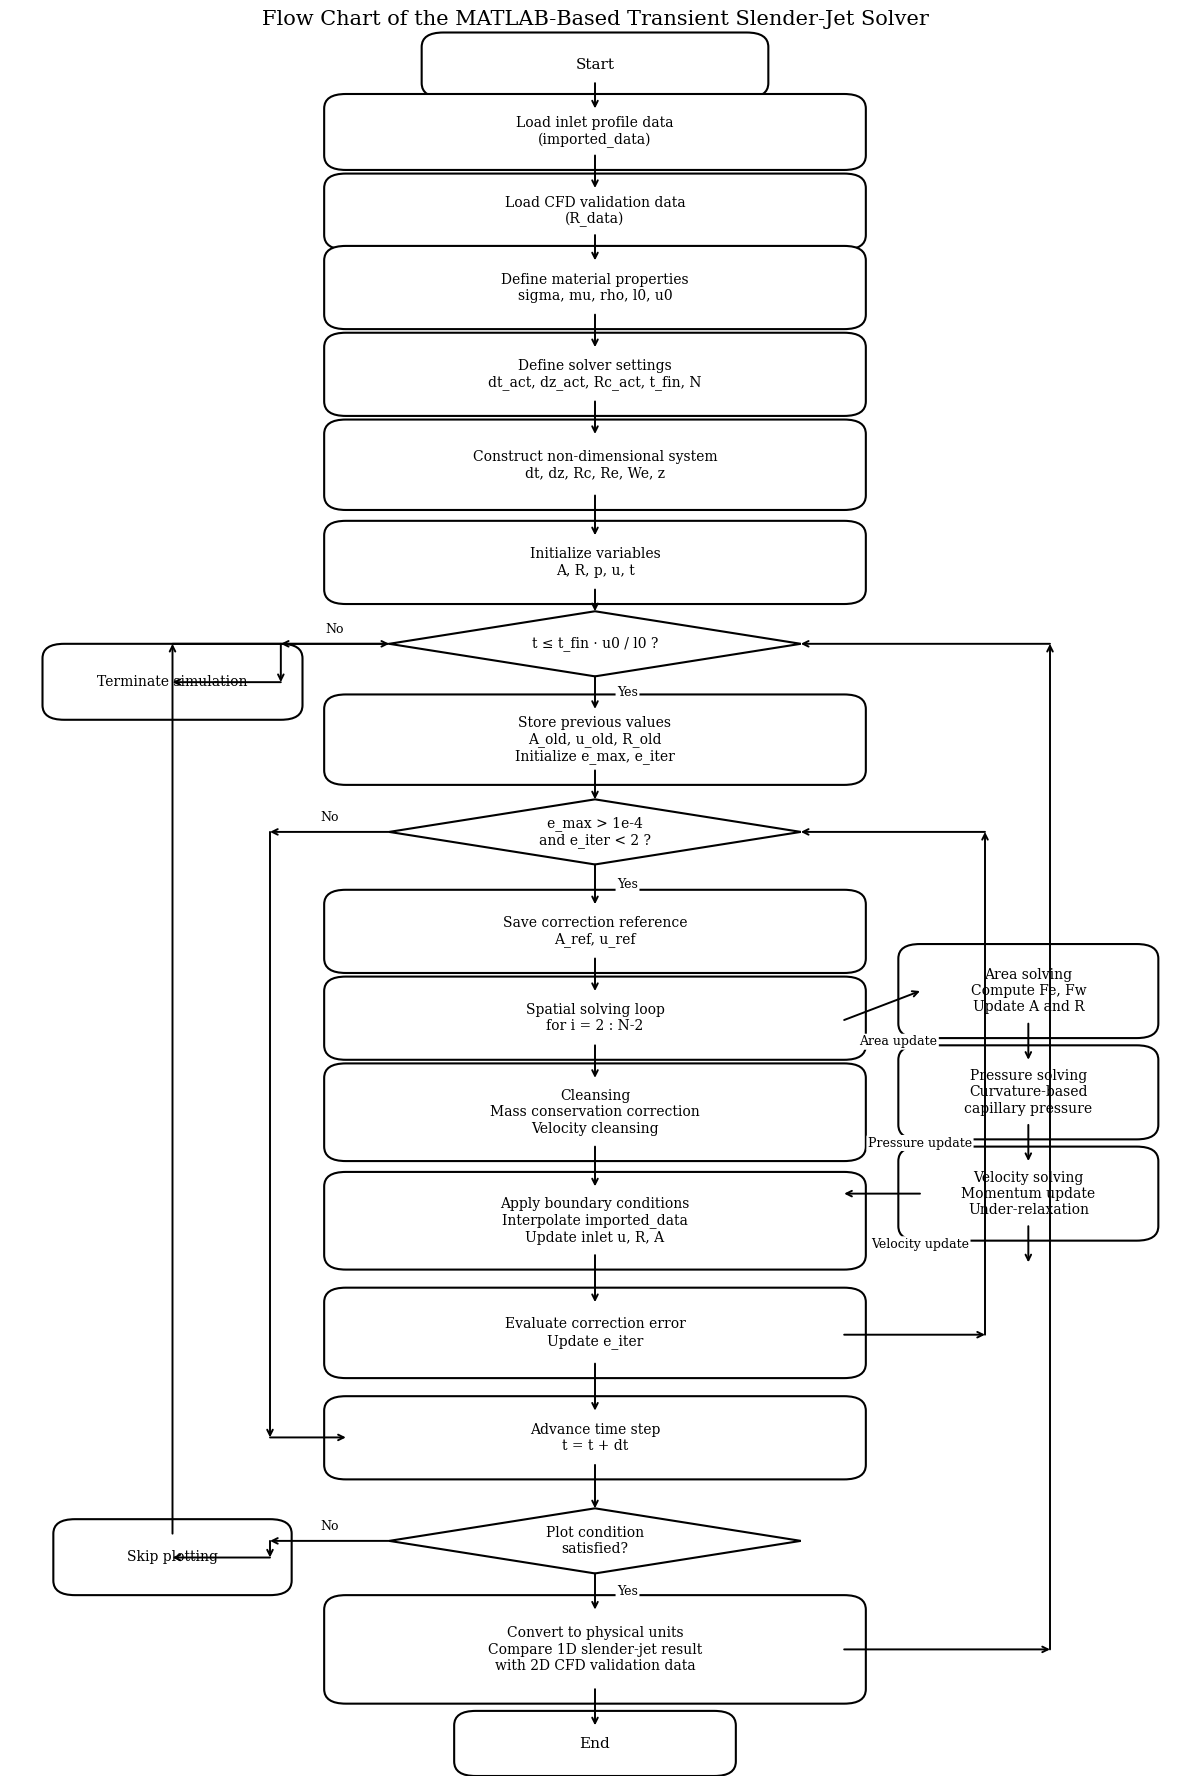

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# ============================================================
# 1. Helper functions
# ============================================================
def add_box(ax, x, y, w, h, text, fontsize=10, lw=1.5):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_diamond(ax, x, y, w, h, text, fontsize=10, lw=1.5):
    pts = [
        (x + w / 2, y + h),
        (x + w,     y + h / 2),
        (x + w / 2, y),
        (x,         y + h / 2)
    ]
    diamond = Polygon(
        pts, closed=True,
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(diamond)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_arrow(ax, x1, y1, x2, y2, text=None, fontsize=9, text_dx=0.0, text_dy=0.0):
    ax.annotate(
        "",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            color="black",
            shrinkA=0,
            shrinkB=0
        )
    )
    if text is not None:
        ax.text(
            (x1 + x2) / 2 + text_dx,
            (y1 + y2) / 2 + text_dy,
            text,
            fontsize=fontsize,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none")
        )

# ============================================================
# 2. Figure canvas
# ============================================================
fig, ax = plt.subplots(figsize=(12, 18))
ax.set_xlim(0, 1.08)
ax.set_ylim(-0.88, 1.56)
ax.axis("off")

# ============================================================
# 3. Main blocks
# ============================================================
add_box(ax, 0.40, 1.46, 0.28, 0.05, "Start", fontsize=11)

add_box(ax, 0.31, 1.36, 0.46, 0.065,
        "Load inlet profile data\n(imported_data)", fontsize=10)

add_box(ax, 0.31, 1.25, 0.46, 0.065,
        "Load CFD validation data\n(R_data)", fontsize=10)

add_box(ax, 0.31, 1.14, 0.46, 0.075,
        "Define material properties\n"
        "sigma, mu, rho, l0, u0", fontsize=10)

add_box(ax, 0.31, 1.02, 0.46, 0.075,
        "Define solver settings\n"
        "dt_act, dz_act, Rc_act, t_fin, N", fontsize=10)

add_box(ax, 0.31, 0.89, 0.46, 0.085,
        "Construct non-dimensional system\n"
        "dt, dz, Rc, Re, We, z", fontsize=10)

add_box(ax, 0.31, 0.76, 0.46, 0.075,
        "Initialize variables\n"
        "A, R, p, u, t", fontsize=10)

add_diamond(ax, 0.35, 0.64, 0.38, 0.09,
            "t ≤ t_fin · u0 / l0 ?", fontsize=10)

add_box(ax, 0.31, 0.51, 0.46, 0.085,
        "Store previous values\n"
        "A_old, u_old, R_old\n"
        "Initialize e_max, e_iter", fontsize=10)

add_diamond(ax, 0.35, 0.38, 0.38, 0.09,
            "e_max > 1e-4\nand e_iter < 2 ?", fontsize=10)

add_box(ax, 0.31, 0.25, 0.46, 0.075,
        "Save correction reference\n"
        "A_ref, u_ref", fontsize=10)

add_box(ax, 0.31, 0.13, 0.46, 0.075,
        "Spatial solving loop\n"
        "for i = 2 : N-2", fontsize=10)

add_box(ax, 0.31, -0.01, 0.46, 0.095,
        "Cleansing\n"
        "Mass conservation correction\n"
        "Velocity cleansing", fontsize=10)

add_box(ax, 0.31, -0.16, 0.46, 0.095,
        "Apply boundary conditions\n"
        "Interpolate imported_data\n"
        "Update inlet u, R, A", fontsize=10)

add_box(ax, 0.31, -0.31, 0.46, 0.085,
        "Evaluate correction error\n"
        "Update e_iter", fontsize=10)

add_box(ax, 0.31, -0.45, 0.46, 0.075,
        "Advance time step\n"
        "t = t + dt", fontsize=10)

add_diamond(ax, 0.35, -0.60, 0.38, 0.09,
            "Plot condition\nsatisfied?", fontsize=10)

add_box(ax, 0.31, -0.76, 0.46, 0.11,
        "Convert to physical units\n"
        "Compare 1D slender-jet result\n"
        "with 2D CFD validation data", fontsize=10)

add_box(ax, 0.43, -0.86, 0.22, 0.05, "End", fontsize=11)

# ============================================================
# 4. Right-side detailed solving blocks
# ============================================================
add_box(ax, 0.84, 0.16, 0.20, 0.09,
        "Area solving\n"
        "Compute Fe, Fw\n"
        "Update A and R", fontsize=10)

add_box(ax, 0.84, 0.02, 0.20, 0.09,
        "Pressure solving\n"
        "Curvature-based\n"
        "capillary pressure", fontsize=10)

add_box(ax, 0.84, -0.12, 0.20, 0.09,
        "Velocity solving\n"
        "Momentum update\n"
        "Under-relaxation", fontsize=10)

# ============================================================
# 5. Left-side auxiliary blocks
# ============================================================
add_box(ax, 0.05, 0.60, 0.20, 0.065,
        "Terminate simulation", fontsize=10)

add_box(ax, 0.06, -0.61, 0.18, 0.065,
        "Skip plotting", fontsize=10)

# ============================================================
# 6. Main vertical arrows
# ============================================================
add_arrow(ax, 0.54, 1.46, 0.54, 1.425)
add_arrow(ax, 0.54, 1.36, 0.54, 1.315)
add_arrow(ax, 0.54, 1.25, 0.54, 1.215)
add_arrow(ax, 0.54, 1.14, 0.54, 1.095)
add_arrow(ax, 0.54, 1.02, 0.54, 0.975)
add_arrow(ax, 0.54, 0.89, 0.54, 0.835)
add_arrow(ax, 0.54, 0.76, 0.54, 0.73)
add_arrow(ax, 0.54, 0.64, 0.54, 0.595, text="Yes", text_dx=0.03)

add_arrow(ax, 0.54, 0.51, 0.54, 0.47)
add_arrow(ax, 0.54, 0.38, 0.54, 0.325, text="Yes", text_dx=0.03)
add_arrow(ax, 0.54, 0.25, 0.54, 0.205)
add_arrow(ax, 0.54, 0.13, 0.54, 0.085)
add_arrow(ax, 0.54, -0.01, 0.54, -0.065)
add_arrow(ax, 0.54, -0.16, 0.54, -0.225)
add_arrow(ax, 0.54, -0.31, 0.54, -0.375)
add_arrow(ax, 0.54, -0.45, 0.54, -0.51)
add_arrow(ax, 0.54, -0.60, 0.54, -0.65, text="Yes", text_dx=0.03)
add_arrow(ax, 0.54, -0.76, 0.54, -0.81)

# ============================================================
# 7. Time-loop No branch
# ============================================================
add_arrow(ax, 0.35, 0.685, 0.25, 0.685, text="No", text_dy=0.02)
add_arrow(ax, 0.25, 0.685, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.25, 0.632)
add_arrow(ax, 0.25, 0.632, 0.15, 0.632)

# ============================================================
# 8. Correction-loop No branch
# ============================================================
add_arrow(ax, 0.35, 0.425, 0.24, 0.425, text="No", text_dy=0.02)
add_arrow(ax, 0.24, 0.425, 0.24, -0.412)
add_arrow(ax, 0.24, -0.412, 0.31, -0.412)

# ============================================================
# 9. Plot-condition No branch
# ============================================================
add_arrow(ax, 0.35, -0.555, 0.24, -0.555, text="No", text_dy=0.02)
add_arrow(ax, 0.24, -0.555, 0.24, -0.578)
add_arrow(ax, 0.24, -0.578, 0.15, -0.578)

# ============================================================
# 10. Return loops
# ============================================================
# Return from plotting block to time decision
add_arrow(ax, 0.77, -0.705, 0.96, -0.705)
add_arrow(ax, 0.96, -0.705, 0.96, 0.685)
add_arrow(ax, 0.96, 0.685, 0.73, 0.685)

# Return from skip plotting to time decision
add_arrow(ax, 0.15, -0.545, 0.15, 0.685)
add_arrow(ax, 0.15, 0.685, 0.35, 0.685)

# ============================================================
# 11. Spatial-solving detailed branch
# ============================================================
add_arrow(ax, 0.77, 0.165, 0.84, 0.205)
add_arrow(ax, 0.94, 0.16, 0.94, 0.11, text="Area update", fontsize=9, text_dx=-0.12)
add_arrow(ax, 0.94, 0.02, 0.94, -0.03, text="Pressure update", fontsize=9, text_dx=-0.10)
add_arrow(ax, 0.94, -0.12, 0.94, -0.17, text="Velocity update", fontsize=9, text_dx=-0.10)

# Return from velocity solving to cleansing
add_arrow(ax, 0.84, -0.075, 0.77, -0.075)

# Return from error evaluation to correction decision
add_arrow(ax, 0.77, -0.27, 0.90, -0.27)
add_arrow(ax, 0.90, -0.27, 0.90, 0.425)
add_arrow(ax, 0.90, 0.425, 0.73, 0.425)

# ============================================================
# 12. Title
# ============================================================
ax.text(
    0.54, 1.535,
    "Flow Chart of the MATLAB-Based Transient Slender-Jet Solver",
    ha="center", va="bottom", fontsize=15
)

plt.tight_layout()
plt.show()

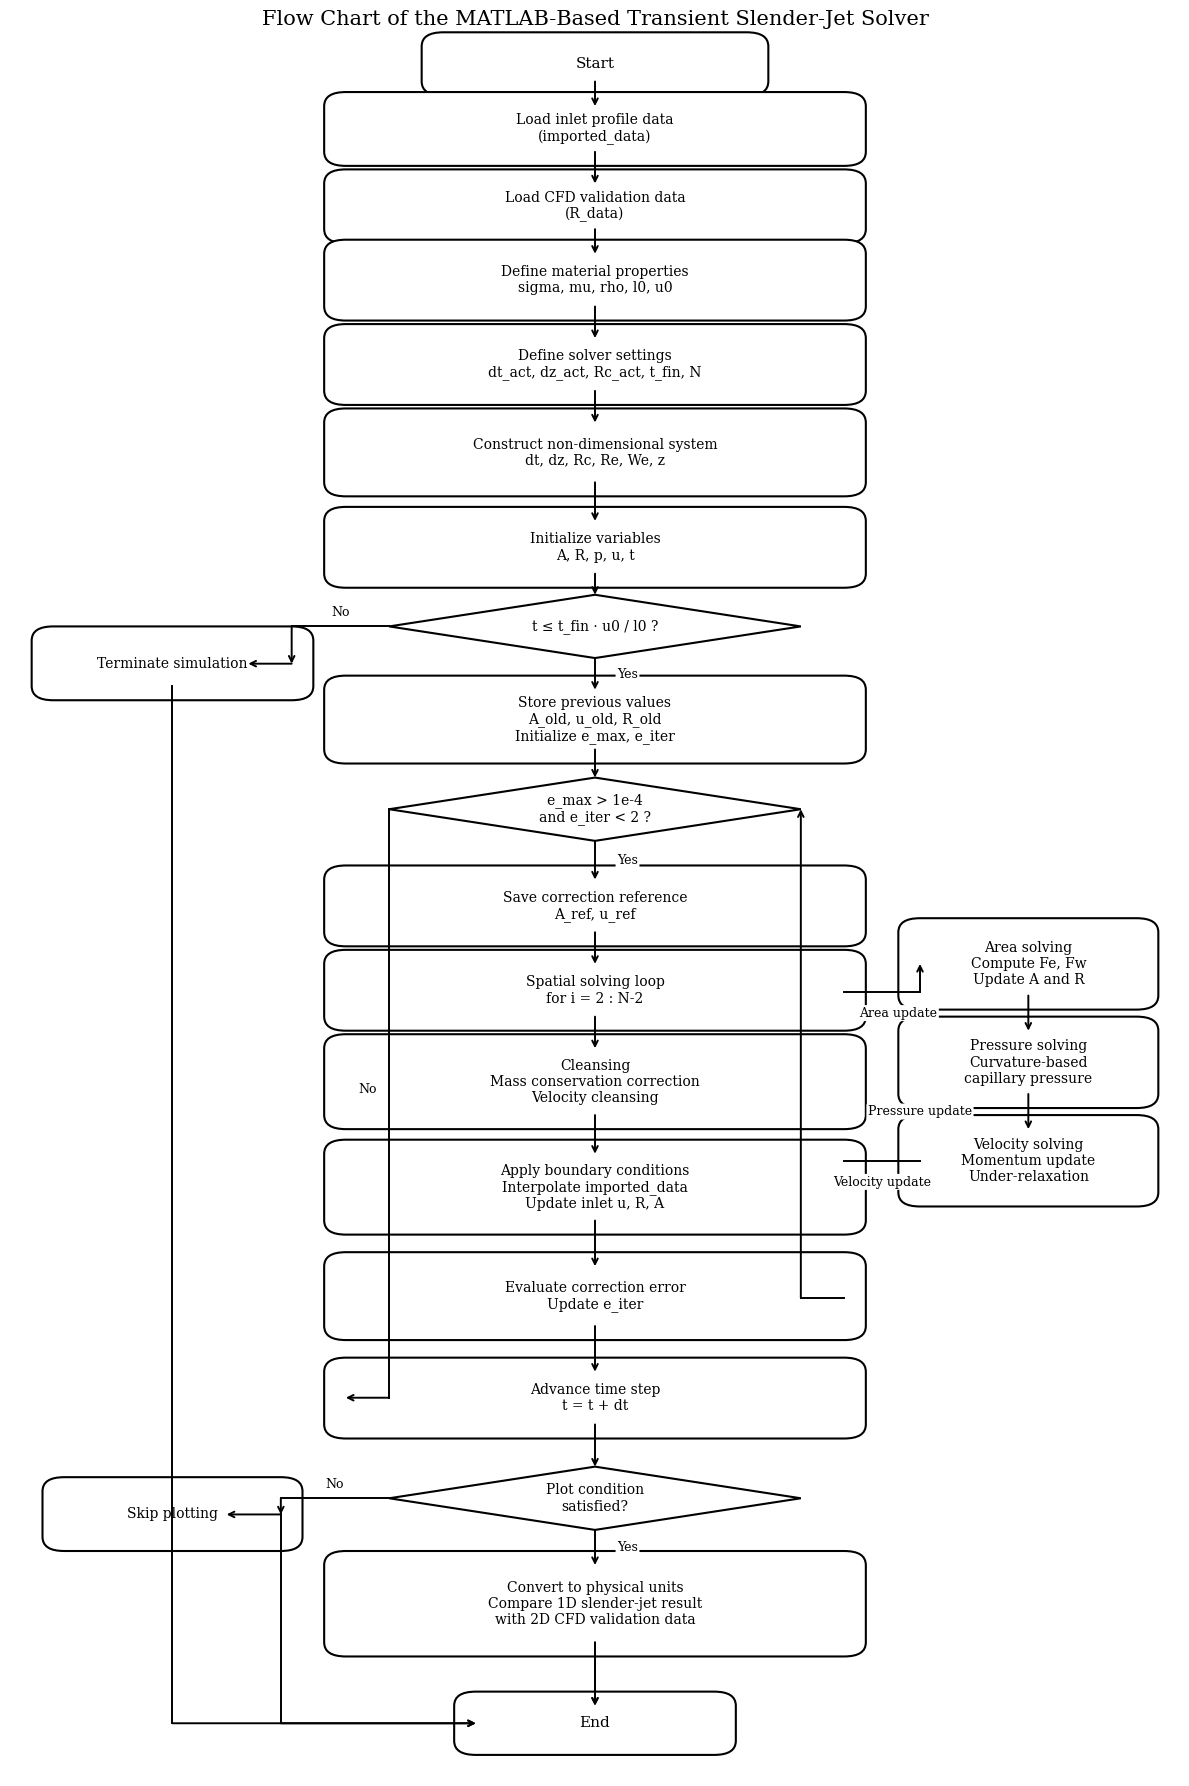

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# ============================================================
# 1. Helper functions
# ============================================================
def add_box(ax, x, y, w, h, text, fontsize=10, lw=1.5):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_diamond(ax, x, y, w, h, text, fontsize=10, lw=1.5):
    pts = [
        (x + w / 2, y + h),
        (x + w,     y + h / 2),
        (x + w / 2, y),
        (x,         y + h / 2)
    ]
    diamond = Polygon(
        pts, closed=True,
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(diamond)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_arrow(ax, x1, y1, x2, y2, text=None, fontsize=9, text_dx=0.0, text_dy=0.0):
    ax.annotate(
        "",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            color="black",
            shrinkA=0,
            shrinkB=0
        )
    )
    if text is not None:
        ax.text(
            (x1 + x2) / 2 + text_dx,
            (y1 + y2) / 2 + text_dy,
            text,
            fontsize=fontsize,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none")
        )

def add_ortho_arrow(ax, x1, y1, x2, y2, mode="hv", text=None, fontsize=9, text_pos=0.5, text_dx=0.0, text_dy=0.0):
    """
    mode = "hv" : horizontal then vertical
    mode = "vh" : vertical then horizontal
    """
    if mode == "hv":
        xm, ym = x2, y1
        ax.plot([x1, xm], [y1, y1], color="black", lw=1.4)
        ax.annotate(
            "", xy=(x2, y2), xytext=(xm, y1),
            arrowprops=dict(arrowstyle="->", lw=1.4, color="black", shrinkA=0, shrinkB=0)
        )
        if text is not None:
            xt = x1 + (xm - x1) * text_pos
            yt = y1
            ax.text(
                xt + text_dx, yt + text_dy, text,
                fontsize=fontsize, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none")
            )
    elif mode == "vh":
        xm, ym = x1, y2
        ax.plot([x1, x1], [y1, ym], color="black", lw=1.4)
        ax.annotate(
            "", xy=(x2, y2), xytext=(x1, ym),
            arrowprops=dict(arrowstyle="->", lw=1.4, color="black", shrinkA=0, shrinkB=0)
        )
        if text is not None:
            xt = x1
            yt = y1 + (ym - y1) * text_pos
            ax.text(
                xt + text_dx, yt + text_dy, text,
                fontsize=fontsize, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none")
            )

# ============================================================
# 2. Figure canvas
# ============================================================
fig, ax = plt.subplots(figsize=(12, 18))
ax.set_xlim(0, 1.08)
ax.set_ylim(-0.95, 1.56)
ax.axis("off")

# ============================================================
# 3. Main blocks
# ============================================================
add_box(ax, 0.40, 1.46, 0.28, 0.05, "Start", fontsize=11)

add_box(ax, 0.31, 1.36, 0.46, 0.065,
        "Load inlet profile data\n(imported_data)", fontsize=10)

add_box(ax, 0.31, 1.25, 0.46, 0.065,
        "Load CFD validation data\n(R_data)", fontsize=10)

add_box(ax, 0.31, 1.14, 0.46, 0.075,
        "Define material properties\n"
        "sigma, mu, rho, l0, u0", fontsize=10)

add_box(ax, 0.31, 1.02, 0.46, 0.075,
        "Define solver settings\n"
        "dt_act, dz_act, Rc_act, t_fin, N", fontsize=10)

add_box(ax, 0.31, 0.89, 0.46, 0.085,
        "Construct non-dimensional system\n"
        "dt, dz, Rc, Re, We, z", fontsize=10)

add_box(ax, 0.31, 0.76, 0.46, 0.075,
        "Initialize variables\n"
        "A, R, p, u, t", fontsize=10)

add_diamond(ax, 0.35, 0.64, 0.38, 0.09,
            "t ≤ t_fin · u0 / l0 ?", fontsize=10)

add_box(ax, 0.31, 0.51, 0.46, 0.085,
        "Store previous values\n"
        "A_old, u_old, R_old\n"
        "Initialize e_max, e_iter", fontsize=10)

add_diamond(ax, 0.35, 0.38, 0.38, 0.09,
            "e_max > 1e-4\nand e_iter < 2 ?", fontsize=10)

add_box(ax, 0.31, 0.25, 0.46, 0.075,
        "Save correction reference\n"
        "A_ref, u_ref", fontsize=10)

add_box(ax, 0.31, 0.13, 0.46, 0.075,
        "Spatial solving loop\n"
        "for i = 2 : N-2", fontsize=10)

add_box(ax, 0.31, -0.01, 0.46, 0.095,
        "Cleansing\n"
        "Mass conservation correction\n"
        "Velocity cleansing", fontsize=10)

add_box(ax, 0.31, -0.16, 0.46, 0.095,
        "Apply boundary conditions\n"
        "Interpolate imported_data\n"
        "Update inlet u, R, A", fontsize=10)

add_box(ax, 0.31, -0.31, 0.46, 0.085,
        "Evaluate correction error\n"
        "Update e_iter", fontsize=10)

add_box(ax, 0.31, -0.45, 0.46, 0.075,
        "Advance time step\n"
        "t = t + dt", fontsize=10)

add_diamond(ax, 0.35, -0.60, 0.38, 0.09,
            "Plot condition\nsatisfied?", fontsize=10)

add_box(ax, 0.31, -0.76, 0.46, 0.11,
        "Convert to physical units\n"
        "Compare 1D slender-jet result\n"
        "with 2D CFD validation data", fontsize=10)

add_box(ax, 0.43, -0.90, 0.22, 0.05, "End", fontsize=11)

# ============================================================
# 4. Right-side detailed solving blocks
# ============================================================
add_box(ax, 0.84, 0.16, 0.20, 0.09,
        "Area solving\n"
        "Compute Fe, Fw\n"
        "Update A and R", fontsize=10)

add_box(ax, 0.84, 0.02, 0.20, 0.09,
        "Pressure solving\n"
        "Curvature-based\n"
        "capillary pressure", fontsize=10)

add_box(ax, 0.84, -0.12, 0.20, 0.09,
        "Velocity solving\n"
        "Momentum update\n"
        "Under-relaxation", fontsize=10)

# ============================================================
# 5. Left-side auxiliary blocks
# ============================================================
add_box(ax, 0.04, 0.60, 0.22, 0.065,
        "Terminate simulation", fontsize=10)

add_box(ax, 0.05, -0.61, 0.20, 0.065,
        "Skip plotting", fontsize=10)

# ============================================================
# 6. Main vertical arrows
# ============================================================
add_arrow(ax, 0.54, 1.46, 0.54, 1.425)
add_arrow(ax, 0.54, 1.36, 0.54, 1.315)
add_arrow(ax, 0.54, 1.25, 0.54, 1.215)
add_arrow(ax, 0.54, 1.14, 0.54, 1.095)
add_arrow(ax, 0.54, 1.02, 0.54, 0.975)
add_arrow(ax, 0.54, 0.89, 0.54, 0.835)
add_arrow(ax, 0.54, 0.76, 0.54, 0.73)
add_arrow(ax, 0.54, 0.64, 0.54, 0.595, text="Yes", text_dx=0.03)

add_arrow(ax, 0.54, 0.51, 0.54, 0.47)
add_arrow(ax, 0.54, 0.38, 0.54, 0.325, text="Yes", text_dx=0.03)
add_arrow(ax, 0.54, 0.25, 0.54, 0.205)
add_arrow(ax, 0.54, 0.13, 0.54, 0.085)
add_arrow(ax, 0.54, -0.01, 0.54, -0.065)
add_arrow(ax, 0.54, -0.16, 0.54, -0.225)
add_arrow(ax, 0.54, -0.31, 0.54, -0.375)
add_arrow(ax, 0.54, -0.45, 0.54, -0.51)
add_arrow(ax, 0.54, -0.60, 0.54, -0.65, text="Yes", text_dx=0.03)
add_arrow(ax, 0.54, -0.76, 0.54, -0.85)

# ============================================================
# 7. Time-loop No branch
# ============================================================
add_ortho_arrow(ax, 0.35, 0.685, 0.26, 0.632, mode="hv", text="No", text_dy=0.02)
add_arrow(ax, 0.26, 0.632, 0.22, 0.632)

# ============================================================
# 8. Correction-loop No branch
# ============================================================
add_ortho_arrow(ax, 0.35, 0.425, 0.31, -0.412, mode="vh", text="No", text_dx=-0.02, text_dy=0.02)

# ============================================================
# 9. Plot-condition No branch
# ============================================================
add_ortho_arrow(ax, 0.35, -0.555, 0.25, -0.578, mode="hv", text="No", text_dy=0.02)
add_arrow(ax, 0.25, -0.578, 0.20, -0.578)

# ============================================================
# 10. Spatial-solving detailed branch
# ============================================================
# Spatial solving -> Area solving
add_ortho_arrow(ax, 0.77, 0.165, 0.84, 0.205, mode="hv")

# Area -> Pressure
add_arrow(ax, 0.94, 0.16, 0.94, 0.11, text="Area update", fontsize=9, text_dx=-0.12)

# Pressure -> Velocity
add_arrow(ax, 0.94, 0.02, 0.94, -0.03, text="Pressure update", fontsize=9, text_dx=-0.10)

# Velocity -> Cleansing
add_ortho_arrow(ax, 0.84, -0.075, 0.77, -0.075, mode="hv", text="Velocity update", fontsize=9, text_dy=-0.03)

# ============================================================
# 11. Correction return loop
# ============================================================
add_ortho_arrow(ax, 0.77, -0.27, 0.73, 0.425, mode="hv")

# ============================================================
# 12. End path
# ============================================================
add_arrow(ax, 0.54, -0.90 + 0.05, 0.54, -0.90 + 0.05)

# Convert block -> End
add_arrow(ax, 0.54, -0.76, 0.54, -0.85)

# Skip plotting -> End
add_ortho_arrow(ax, 0.25, -0.578, 0.43, -0.875, mode="vh")

# Terminate simulation -> End
add_ortho_arrow(ax, 0.15, 0.60, 0.43, -0.875, mode="vh")

# ============================================================
# 13. Title
# ============================================================
ax.text(
    0.54, 1.535,
    "Flow Chart of the MATLAB-Based Transient Slender-Jet Solver",
    ha="center", va="bottom", fontsize=15
)

plt.tight_layout()
plt.show()

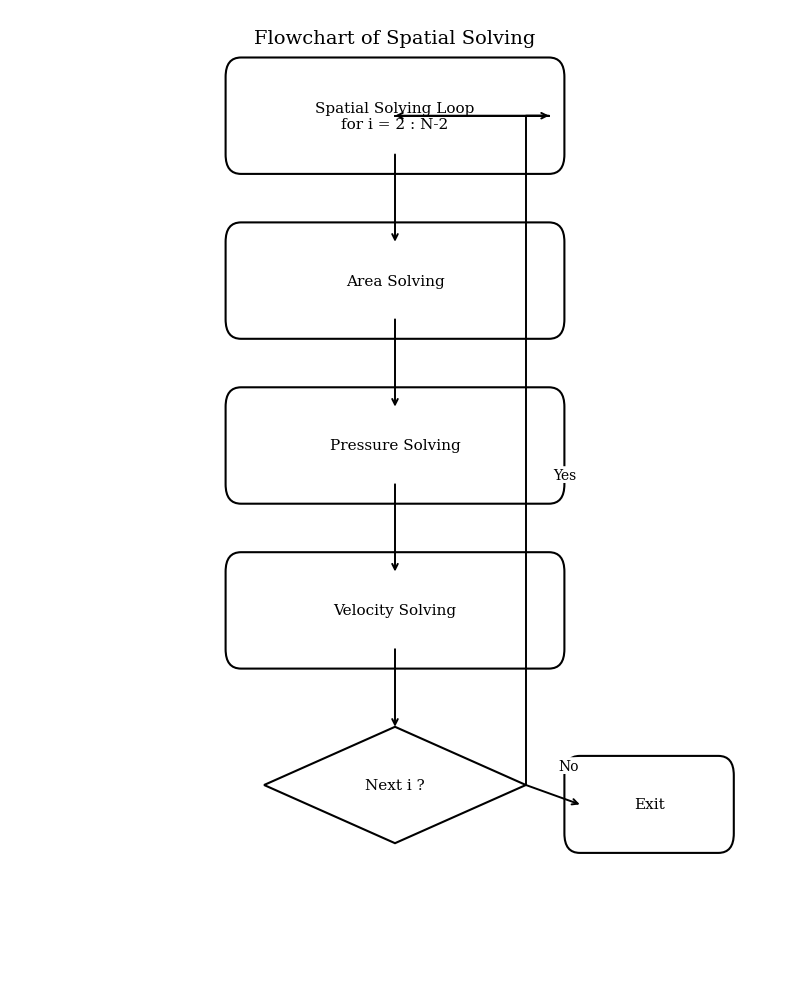

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# ============================================================
# 1. Helper functions
# ============================================================
def add_box(ax, x, y, w, h, text, fontsize=11, lw=1.5):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2,
        text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_diamond(ax, x, y, w, h, text, fontsize=11, lw=1.5):
    pts = [
        (x + w / 2, y + h),
        (x + w,     y + h / 2),
        (x + w / 2, y),
        (x,         y + h / 2)
    ]
    diamond = Polygon(
        pts,
        closed=True,
        linewidth=lw,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(diamond)
    ax.text(
        x + w / 2, y + h / 2,
        text,
        ha="center", va="center",
        fontsize=fontsize
    )

def add_arrow(ax, x1, y1, x2, y2, text=None, fontsize=10, text_dx=0.0, text_dy=0.0):
    ax.annotate(
        "",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            color="black",
            shrinkA=0,
            shrinkB=0
        )
    )
    if text is not None:
        ax.text(
            (x1 + x2) / 2 + text_dx,
            (y1 + y2) / 2 + text_dy,
            text,
            ha="center", va="center",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none")
        )

def add_ortho_arrow(ax, x1, y1, x2, y2, mode="vh", text=None, fontsize=10, text_dx=0.0, text_dy=0.0):
    if mode == "vh":
        ax.plot([x1, x1], [y1, y2], color="black", lw=1.4)
        ax.annotate(
            "",
            xy=(x2, y2), xytext=(x1, y2),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.4,
                color="black",
                shrinkA=0,
                shrinkB=0
            )
        )
        if text is not None:
            ax.text(
                x1 + text_dx, (y1 + y2) / 2 + text_dy,
                text,
                ha="center", va="center",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none")
            )

# ============================================================
# 2. Figure canvas
# ============================================================
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# ============================================================
# 3. Blocks
# ============================================================
add_box(ax, 0.30, 0.85, 0.40, 0.08, "Spatial Solving Loop\nfor i = 2 : N-2")
add_box(ax, 0.30, 0.68, 0.40, 0.08, "Area Solving")
add_box(ax, 0.30, 0.51, 0.40, 0.08, "Pressure Solving")
add_box(ax, 0.30, 0.34, 0.40, 0.08, "Velocity Solving")
add_diamond(ax, 0.33, 0.14, 0.34, 0.12, "Next i ?")

add_box(ax, 0.74, 0.15, 0.18, 0.06, "Exit")

# ============================================================
# 4. Main vertical arrows
# ============================================================
add_arrow(ax, 0.50, 0.85, 0.50, 0.76)
add_arrow(ax, 0.50, 0.68, 0.50, 0.59)
add_arrow(ax, 0.50, 0.51, 0.50, 0.42)
add_arrow(ax, 0.50, 0.34, 0.50, 0.26)

# ============================================================
# 5. Decision branches
# ============================================================
# Yes -> back to loop
add_ortho_arrow(ax, 0.67, 0.20, 0.70, 0.89, mode="vh")
ax.plot([0.70, 0.70], [0.89, 0.89], color="black", lw=1.4)
ax.annotate(
    "",
    xy=(0.70, 0.89), xytext=(0.70, 0.89),
    arrowprops=dict(arrowstyle="->", lw=1.4, color="black")
)
ax.plot([0.70, 0.70], [0.89, 0.89], color="black", lw=1.4)
ax.plot([0.70, 0.50], [0.89, 0.89], color="black", lw=1.4)
ax.annotate(
    "",
    xy=(0.50, 0.89), xytext=(0.70, 0.89),
    arrowprops=dict(arrowstyle="->", lw=1.4, color="black", shrinkA=0, shrinkB=0)
)
ax.text(0.72, 0.52, "Yes", fontsize=10, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none"))

# No -> exit
add_arrow(ax, 0.67, 0.20, 0.74, 0.18, text="No", text_dx=0.02, text_dy=0.03)

# ============================================================
# 6. Title
# ============================================================
ax.text(
    0.5, 0.97,
    "Flowchart of Spatial Solving",
    ha="center", va="center", fontsize=14
)

plt.tight_layout()
plt.show()